# FEA sequence model error patterns in the raw FEA signals

This notebook analyzes whether the raw FEA patterns differ between **correctly classified** and **misclassified** test-set reenactments of the final FEA sequence model.

This analysis is intentionally kept separate from `04_analyze_category_fea_patterns.ipynb` because the two notebooks answer different questions:

- `04_analyze_category_fea_patterns.ipynb` characterizes the **dataset** and may therefore use train, validation, and test data.
- This notebook analyzes the behavior of the **final FEA sequence model** and therefore uses the **held-out test set only**.

The primary comparison is descriptive:

> Within the same ground-truth expression category, how do the mean raw FEA coefficients differ between reenactments that the FEA sequence model classifies correctly and incorrectly?

The analysis does **not** establish that a coefficient is important to the model. A difference between correct and incorrect samples is an error-associated signal pattern, not a model-reliance measure. Model reliance requires the later perturbation/permutation analysis.

Outputs are written to:

`outputs/05_fea_sequence_model_error_patterns/`


**Extension:** Sections 15–19 add directed confusion comparisons, class references, semantic group summaries, individual-sample distributions, participant sensitivity, and a numerical narrative report. No trajectory analysis is performed.


## 1. Imports and paths

Run this notebook from:

`emohevrdb-dfer/6_discussion/fea_analysis/`

The notebook expects:

- `data/dfea_test.csv`
- `data/facs_fea_mapping.json`
- the existing `dynamic_test_predictions.csv` from the dynamic significance-test workflow.


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

ANALYSIS_DIR = Path.cwd()
OUTPUT_DIR = ANALYSIS_DIR / "outputs" / "05_fea_sequence_model_error_patterns"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = ANALYSIS_DIR / "data"

DFEA_TEST_PATH = DATA_DIR / "dfea_test.csv"
MAPPING_PATH = DATA_DIR / "facs_fea_mapping.json"

PREDICTIONS_PATH = (
    ANALYSIS_DIR.parent
    / "significance-tests"
    / "dynamic-significance-tests"
    / "dynamic_test_predictions.csv"
)

print("DFEA test data:", DFEA_TEST_PATH.resolve())
print("Mapping:", MAPPING_PATH.resolve())
print("Predictions:", PREDICTIONS_PATH.resolve())
print("Output directory:", OUTPUT_DIR.resolve())


DFEA test data: /workspace/repos/emohevrdb-dfer/6_discussion/fea_analysis/data/dfea_test.csv
Mapping: /workspace/repos/emohevrdb-dfer/6_discussion/fea_analysis/data/facs_fea_mapping.json
Predictions: /workspace/repos/emohevrdb-dfer/6_discussion/significance-tests/dynamic-significance-tests/dynamic_test_predictions.csv
Output directory: /workspace/repos/emohevrdb-dfer/6_discussion/fea_analysis/outputs/05_fea_sequence_model_error_patterns


## 2. Canonical schema and class order


In [2]:
CATEGORY_ORDER = [
    "Anger",
    "Disgust",
    "Fear",
    "Happiness",
    "Neutral",
    "Sadness",
    "Surprise",
]

META_COLUMNS = [
    "reenactment_id",
    "split",
    "sequence_timestamp",
    "set_id",
    "participant_id",
    "level_id",
    "emoji_id",
    "timestep",
    "observation_timestamp",
    "is_reference_observation",
    "true_label_id",
    "true_label",
]

FEA_COLUMNS = [
    "BrowLowererL",
    "BrowLowererR",
    "CheekPuffL",
    "CheekPuffR",
    "CheekRaiserL",
    "CheekRaiserR",
    "CheekSuckL",
    "CheekSuckR",
    "ChinRaiserB",
    "ChinRaiserT",
    "DimplerL",
    "DimplerR",
    "EyesClosedL",
    "EyesClosedR",
    "EyesLookDownL",
    "EyesLookDownR",
    "EyesLookLeftL",
    "EyesLookLeftR",
    "EyesLookRightL",
    "EyesLookRightR",
    "EyesLookUpL",
    "EyesLookUpR",
    "InnerBrowRaiserL",
    "InnerBrowRaiserR",
    "JawDrop",
    "JawSidewaysLeft",
    "JawSidewaysRight",
    "JawThrust",
    "LidTightenerL",
    "LidTightenerR",
    "LipCornerDepressorL",
    "LipCornerDepressorR",
    "LipCornerPullerL",
    "LipCornerPullerR",
    "LipFunnelerLB",
    "LipFunnelerLT",
    "LipFunnelerRB",
    "LipFunnelerRT",
    "LipPressorL",
    "LipPressorR",
    "LipPuckerL",
    "LipPuckerR",
    "LipStretcherL",
    "LipStretcherR",
    "LipSuckLB",
    "LipSuckLT",
    "LipSuckRB",
    "LipSuckRT",
    "LipTightenerL",
    "LipTightenerR",
    "LipsToward",
    "LowerLipDepressorL",
    "LowerLipDepressorR",
    "MouthLeft",
    "MouthRight",
    "NoseWrinklerL",
    "NoseWrinklerR",
    "OuterBrowRaiserL",
    "OuterBrowRaiserR",
    "UpperLidRaiserL",
    "UpperLidRaiserR",
    "UpperLipRaiserL",
    "UpperLipRaiserR",
]

assert len(FEA_COLUMNS) == 63
assert len(FEA_COLUMNS) == len(set(FEA_COLUMNS))


## 3. Load and validate test data, predictions, and semantic mapping

`dynamic_test_predictions.csv` contains two rows per reenactment because the image modality has central and side views. The FEA sequence prediction is shared by both rows.

This notebook therefore validates that the FEA predictions are identical within each reenactment and then collapses the table to exactly one row per test reenactment.


In [3]:
dfea_test = pd.read_csv(DFEA_TEST_PATH)
predictions = pd.read_csv(PREDICTIONS_PATH)
mapping = json.loads(MAPPING_PATH.read_text(encoding="utf-8"))

assert dfea_test.columns.tolist() == META_COLUMNS + FEA_COLUMNS
assert dfea_test["split"].eq("test").all()
assert not dfea_test.duplicated(["reenactment_id", "timestep"]).any()
assert dfea_test.groupby("reenactment_id").size().eq(30).all()
assert dfea_test["reenactment_id"].nunique() == 378
assert dfea_test[FEA_COLUMNS].notna().all().all()

required_prediction_columns = [
    "reenactment_id",
    "true_label_id",
    "true_label",
    "fea_pred_id",
    "fea_pred",
]

missing_columns = [
    column
    for column in required_prediction_columns
    if column not in predictions.columns
]
assert not missing_columns, f"Missing prediction columns: {missing_columns}"

rows_per_reenactment = predictions.groupby("reenactment_id").size()
assert rows_per_reenactment.eq(2).all(), (
    "Expected two view-level rows per reenactment in dynamic_test_predictions.csv."
)

for column in [
    "true_label_id",
    "true_label",
    "fea_pred_id",
    "fea_pred",
]:
    assert predictions.groupby("reenactment_id")[column].nunique().le(1).all(), (
        f"{column} is not stable within reenactment."
    )

fea_probability_columns = [
    column
    for column in predictions.columns
    if column.startswith("fea_prob_")
]

for column in fea_probability_columns:
    assert predictions.groupby("reenactment_id")[column].nunique().le(1).all(), (
        f"{column} is not stable within reenactment."
    )

prediction_columns = required_prediction_columns + fea_probability_columns

fea_predictions = (
    predictions[prediction_columns]
    .drop_duplicates("reenactment_id")
    .copy()
)

assert len(fea_predictions) == 378
assert fea_predictions["reenactment_id"].is_unique

fea_predictions["correct"] = (
    fea_predictions["true_label_id"] == fea_predictions["fea_pred_id"]
)
fea_predictions["classification_result"] = np.where(
    fea_predictions["correct"],
    "Correct",
    "Incorrect",
)

accuracy = fea_predictions["correct"].mean()

print(
    f"FEA sequence model: "
    f"{fea_predictions['correct'].sum()}/{len(fea_predictions)} correct "
    f"({accuracy:.2%})."
)
print("Mapping version:", mapping.get("mapping_version", "unknown"))

# Reject missing labels and inconsistent sequence metadata before collapsing rows.
assert predictions[required_prediction_columns].notna().all().all()
assert np.isfinite(dfea_test[FEA_COLUMNS].to_numpy()).all()
assert dfea_test[FEA_COLUMNS].ge(0).all().all() and dfea_test[FEA_COLUMNS].le(1).all().all()
for column in ['participant_id', 'true_label', 'true_label_id', 'split']:
    assert dfea_test.groupby('reenactment_id')[column].nunique(dropna=False).eq(1).all()
assert set(fea_predictions.reenactment_id) == set(dfea_test.reenactment_id)
assert fea_predictions['correct'].eq(fea_predictions.true_label.eq(fea_predictions.fea_pred)).all()
assert set(fea_predictions.fea_pred).issubset(CATEGORY_ORDER)


FEA sequence model: 296/378 correct (78.31%).
Mapping version: 1.2.1


## 4. Aggregate each test sequence to its mean raw FEA profile

To stay directly comparable with the primary raw heatmaps from `04_analyze_category_fea_patterns.ipynb`, each 30-observation sequence is summarized using the **sequence mean**.

No standardization or neutral centering is applied to the primary heatmaps in this notebook.


In [4]:
REENACTMENT_META = [
    "reenactment_id",
    "split",
    "sequence_timestamp",
    "set_id",
    "participant_id",
    "level_id",
    "emoji_id",
    "true_label_id",
    "true_label",
]

metadata = (
    dfea_test[REENACTMENT_META]
    .drop_duplicates("reenactment_id")
    .set_index("reenactment_id")
    .sort_index()
)

sequence_mean = (
    dfea_test
    .groupby("reenactment_id", sort=True)[FEA_COLUMNS]
    .mean()
)

assert sequence_mean.index.equals(metadata.index)

reenactment_fea = (
    metadata
    .join(sequence_mean)
    .reset_index()
)

analysis_df = reenactment_fea.merge(
    fea_predictions,
    on="reenactment_id",
    how="inner",
    validate="one_to_one",
    suffixes=("", "_prediction"),
)

assert len(analysis_df) == 378
assert analysis_df["true_label_id"].eq(
    analysis_df["true_label_id_prediction"]
).all()
assert analysis_df["true_label"].eq(
    analysis_df["true_label_prediction"]
).all()

analysis_df = analysis_df.drop(
    columns=[
        "true_label_id_prediction",
        "true_label_prediction",
    ]
)

analysis_df.to_csv(
    OUTPUT_DIR / "test_reenactment_fea_with_model_predictions.csv",
    index=False,
)

display(analysis_df.head())


,reenactment_id,split,sequence_timestamp,set_id,participant_id,level_id,emoji_id,true_label_id,true_label,BrowLowererL,BrowLowererR,CheekPuffL,CheekPuffR,CheekRaiserL,CheekRaiserR,CheekSuckL,CheekSuckR,ChinRaiserB,ChinRaiserT,DimplerL,DimplerR,EyesClosedL,EyesClosedR,EyesLookDownL,EyesLookDownR,EyesLookLeftL,EyesLookLeftR,EyesLookRightL,EyesLookRightR,EyesLookUpL,EyesLookUpR,InnerBrowRaiserL,InnerBrowRaiserR,JawDrop,JawSidewaysLeft,JawSidewaysRight,JawThrust,LidTightenerL,LidTightenerR,LipCornerDepressorL,LipCornerDepressorR,LipCornerPullerL,LipCornerPullerR,LipFunnelerLB,LipFunnelerLT,LipFunnelerRB,LipFunnelerRT,LipPressorL,LipPressorR,LipPuckerL,LipPuckerR,LipStretcherL,LipStretcherR,LipSuckLB,LipSuckLT,LipSuckRB,LipSuckRT,LipTightenerL,LipTightenerR,LipsToward,LowerLipDepressorL,LowerLipDepressorR,MouthLeft,MouthRight,NoseWrinklerL,NoseWrinklerR,OuterBrowRaiserL,OuterBrowRaiserR,UpperLidRaiserL,UpperLidRaiserR,UpperLipRaiserL,UpperLipRaiserR,fea_pred_id,fea_pred,fea_prob_anger,fea_prob_disgust,fea_prob_fear,fea_prob_happiness,fea_prob_neutral,fea_prob_sadness,fea_prob_surprise,correct,classification_result
0,1700478995850-2-1-1-0-0,test,1700478995850,2,1,1,0,0,Anger,0.223092,0.248558,4.586167e-02,4.713184e-02,0.084597,0.054520,1.401298e-45,1.401298e-45,2.064964e-01,0.172893,4.641351e-17,2.820168e-17,0.002558,3.515584e-02,0.002150,9.445732e-03,0.007196,0.052455,0.040981,0.00000,0.068054,0.067955,0.058446,0.067597,0.027385,5.065468e-02,0.052946,0.016728,0.131511,5.358323e-02,0.027425,0.016100,1.441377e-15,1.328162e-15,2.269037e-03,4.371917e-02,6.914283e-03,4.409795e-02,1.401298e-45,1.401298e-45,0.248465,2.569245e-01,0.008605,0.000818,0.000707,0.022969,0.000197,0.010669,1.350607e-01,1.135734e-01,0.034223,1.333448e-02,6.485995e-03,1.005199e-08,6.979022e-09,2.847375e-03,3.147109e-03,5.161996e-14,0.000106,1.401298e-45,1.401298e-45,0.016626,1.037630e-02,0,Anger,0.519205,0.040495,0.002168,0.001112,0.004604,0.416216,0.016200,True,Correct
1,1700478998549-2-1-1-1-5,test,1700478998549,2,1,1,1,5,Sadness,0.094480,0.045010,7.577448e-03,6.172956e-03,0.041957,0.014820,1.401298e-45,1.401298e-45,3.888779e-01,0.337994,1.375618e-05,1.160487e-05,0.020020,1.179088e-02,0.049760,4.816843e-02,0.000000,0.044529,0.042060,0.00000,0.000000,0.000000,0.061237,0.065050,0.019430,2.235537e-02,0.019097,0.048600,0.016761,2.119900e-03,0.815554,0.795844,1.999790e-05,1.582965e-05,6.623035e-02,3.724961e-02,6.550301e-02,3.628417e-02,1.401298e-45,1.401298e-45,0.025754,3.523743e-02,0.135971,0.137012,0.001204,0.014062,0.008118,0.004471,6.429307e-02,4.780819e-02,0.021351,8.822252e-04,8.820727e-04,9.391553e-11,7.925856e-21,3.373950e-04,3.818396e-03,3.155241e-05,0.011380,1.401298e-45,1.401298e-45,0.000005,8.405012e-07,5,Sadness,0.000704,0.000070,0.000028,0.000004,0.000009,0.999097,0.000089,True,Correct
2,1700479001137-2-1-1-2-3,test,1700479001137,2,1,1,2,3,Happiness,0.000002,0.000002,2.426571e-11,2.437032e-11,0.158277,0.166209,1.401298e-45,1.401298e-45,3.353203e-15,0.165736,4.787423e-01,4.768158e-01,0.009758,2.030711e-15,0.009543,2.013840e-12,0.053694,0.140010,0.000000,0.00000,0.044733,0.044517,0.021842,0.039871,0.560646,1.256906e-11,0.009557,0.299710,0.110610,1.431558e-10,0.011147,0.015321,3.577676e-01,3.531083e-01,1.035405e-21,1.120500e-16,1.261667e-21,9.591109e-16,1.354821e-09,1.401298e-45,0.001071,4.682246e-13,0.232302,0.263949,0.111002,0.151666,0.076577,0.132607,5.277947e-17,4.105216e-17,0.028743,1.924846e-01,2.041923e-01,6.905036e-23,6.572523e-04,1.487640e-16,1.610015e-14,2.751507e-02,0.046148,1.401298e-45,1.401298e-45,0.621757,6.316559e-01,3,Happiness,0.000408,0.000733,0.000720,0.997663,0.000053,0.000091,0.000331,True,Correct
3,1700479004312-2-1-1-3-0,test,1700479004312,2,1,1,3,0,Anger,0.034080,0.025056,2.083358e-03,2.915102e-03,0.042228,0.017948,1.401298e-45,1.401298e-45,3.486791e-02,0.032642,8.764961e-23,2.265296e-23,0.002803,3.318854e-04,0.000000,0.000000e+00,0.000000,0.000000,0.134256,0.04777,0.195753,0.196614,0.007921,0.004476,0.014463,6.827924e-03,0.007823,0

## 5. Correct/incorrect counts by ground-truth category

All category-specific comparisons below are grouped by the **true expression label**.

For example, `Anger — Incorrect` means:

> ground truth = Anger, but the FEA sequence model predicted another category.

It does **not** mean all samples incorrectly predicted *as* Anger.


In [5]:
error_counts = (
    analysis_df
    .groupby(
        ["true_label", "classification_result"],
        observed=True,
    )
    .agg(
        n_reenactments=("reenactment_id", "nunique"),
        n_participants=("participant_id", "nunique"),
    )
    .reset_index()
)

count_grid = (
    error_counts
    .pivot(
        index="true_label",
        columns="classification_result",
        values="n_reenactments",
    )
    .reindex(CATEGORY_ORDER)
    .fillna(0)
    .astype(int)
)

participant_grid = (
    error_counts
    .pivot(
        index="true_label",
        columns="classification_result",
        values="n_participants",
    )
    .reindex(CATEGORY_ORDER)
    .fillna(0)
    .astype(int)
)

error_counts.to_csv(
    OUTPUT_DIR / "correct_incorrect_counts_by_category.csv",
    index=False,
)

print("Reenactment counts")
display(count_grid)

print("Participant coverage")
display(participant_grid)


Reenactment counts


classification_result,Correct,Incorrect
true_label,,
Anger,28,26
Disgust,30,24
Fear,33,21
Happiness,54,0
Neutral,51,3
Sadness,48,6
Surprise,52,2


Participant coverage


classification_result,Correct,Incorrect
true_label,,
Anger,6,6
Disgust,7,7
Fear,6,4
Happiness,8,0
Neutral,8,2
Sadness,8,2
Surprise,8,1


## 6. Error destinations

This table provides context for the signal comparison by showing which wrong class was predicted for each true category.


In [6]:
error_confusions = (
    analysis_df.loc[~analysis_df["correct"]]
    .groupby(["true_label", "fea_pred"], observed=True)
    .size()
    .rename("count")
    .reset_index()
    .sort_values(
        ["count", "true_label", "fea_pred"],
        ascending=[False, True, True],
    )
)

error_confusions.to_csv(
    OUTPUT_DIR / "fea_sequence_model_error_confusions.csv",
    index=False,
)

display(error_confusions)


,true_label,fea_pred,count
0,Anger,Disgust,23
5,Disgust,Happiness,10
12,Fear,Surprise,8
4,Disgust,Fear,7
11,Fear,Neutral,6
10,Fear,Happiness,4
15,Sadness,Disgust,4
9,Fear,Disgust,3
2,Anger,Neutral,2
3,Disgust,Anger,2


## 7. Build raw Correct and Incorrect category profiles

Each cell is the ordinary mean raw Meta coefficient across the test reenactments in that ground-truth category and correctness group.

This is a **sample-weighted error analysis**: every test reenactment contributes once.

A category with no errors has no Incorrect profile. Such rows remain missing (`NaN`) rather than being replaced with zeros.


In [7]:
def build_error_profile(df, features, classification_result):
    subset = df.loc[
        df["classification_result"] == classification_result
    ]

    return (
        subset
        .groupby("true_label", observed=True)[features]
        .mean()
        .reindex(CATEGORY_ORDER)
    )


correct_profile_all = build_error_profile(
    analysis_df,
    FEA_COLUMNS,
    "Correct",
)

incorrect_profile_all = build_error_profile(
    analysis_df,
    FEA_COLUMNS,
    "Incorrect",
)

difference_profile_all = (
    incorrect_profile_all - correct_profile_all
)

profile_rows = []

for result_name, profile in [
    ("Correct", correct_profile_all),
    ("Incorrect", incorrect_profile_all),
]:
    long = (
        profile
        .reset_index()
        .melt(
            id_vars="true_label",
            var_name="fea_name",
            value_name="raw_mean",
        )
    )
    long.insert(1, "classification_result", result_name)
    profile_rows.append(long)

correct_incorrect_profiles_long = pd.concat(
    profile_rows,
    ignore_index=True,
)

difference_long = (
    difference_profile_all
    .reset_index()
    .melt(
        id_vars="true_label",
        var_name="fea_name",
        value_name="raw_difference_incorrect_minus_correct",
    )
)

correct_incorrect_profiles_long.to_csv(
    OUTPUT_DIR / "correct_incorrect_raw_fea_profiles_long.csv",
    index=False,
)

difference_long.to_csv(
    OUTPUT_DIR / "incorrect_minus_correct_raw_fea_differences_long.csv",
    index=False,
)


## 8. Heatmap helpers

Correct and Incorrect heatmaps use the **same raw-value color scale** so that visual intensity is directly comparable.

The difference heatmap shows:

$$
\Delta_{c,f}
=
\bar{x}^{\mathrm{Incorrect}}_{c,f}
-
\bar{x}^{\mathrm{Correct}}_{c,f}
$$

Therefore:

- positive values: the FEA coefficient is larger on average in misclassified reenactments;
- negative values: the FEA coefficient is smaller on average in misclassified reenactments.

This is descriptive association, not model importance.


In [8]:
def profile_row_labels(profile, classification_result):
    labels = []

    for category in CATEGORY_ORDER:
        n = int(
            (
                (analysis_df["true_label"] == category)
                & (
                    analysis_df["classification_result"]
                    == classification_result
                )
            ).sum()
        )
        labels.append(f"{category} (n={n})")

    return labels


def difference_row_labels():
    labels = []

    for category in CATEGORY_ORDER:
        n_correct = int(
            (
                (analysis_df["true_label"] == category)
                & analysis_df["correct"]
            ).sum()
        )
        n_incorrect = int(
            (
                (analysis_df["true_label"] == category)
                & ~analysis_df["correct"]
            ).sum()
        )
        labels.append(
            f"{category} (correct={n_correct}, incorrect={n_incorrect})"
        )

    return labels


def save_heatmap(
    matrix,
    y_labels,
    title,
    colorbar_label,
    filename_stem,
    figsize,
    vmin=None,
    vmax=None,
):
    plt.figure(figsize=figsize)

    image = plt.imshow(
        matrix.to_numpy(),
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        cmap="RdBu_r" if vmin is not None and vmin < 0 else "viridis",
    )

    plt.colorbar(
        image,
        label=colorbar_label,
    )

    plt.xticks(
        np.arange(matrix.shape[1]),
        matrix.columns,
        rotation=90,
    )
    plt.yticks(
        np.arange(matrix.shape[0]),
        y_labels,
    )

    plt.xlabel("FEA channel")
    plt.ylabel("Ground-truth expression category")
    plt.title(title)
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / f"{filename_stem}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.savefig(
        OUTPUT_DIR / f"{filename_stem}.pdf",
        bbox_inches="tight",
    )

    plt.show()


## 9. All 63 FEAs: Correct versus Incorrect

These are the full raw-signal heatmaps intended primarily for supplementary analysis.


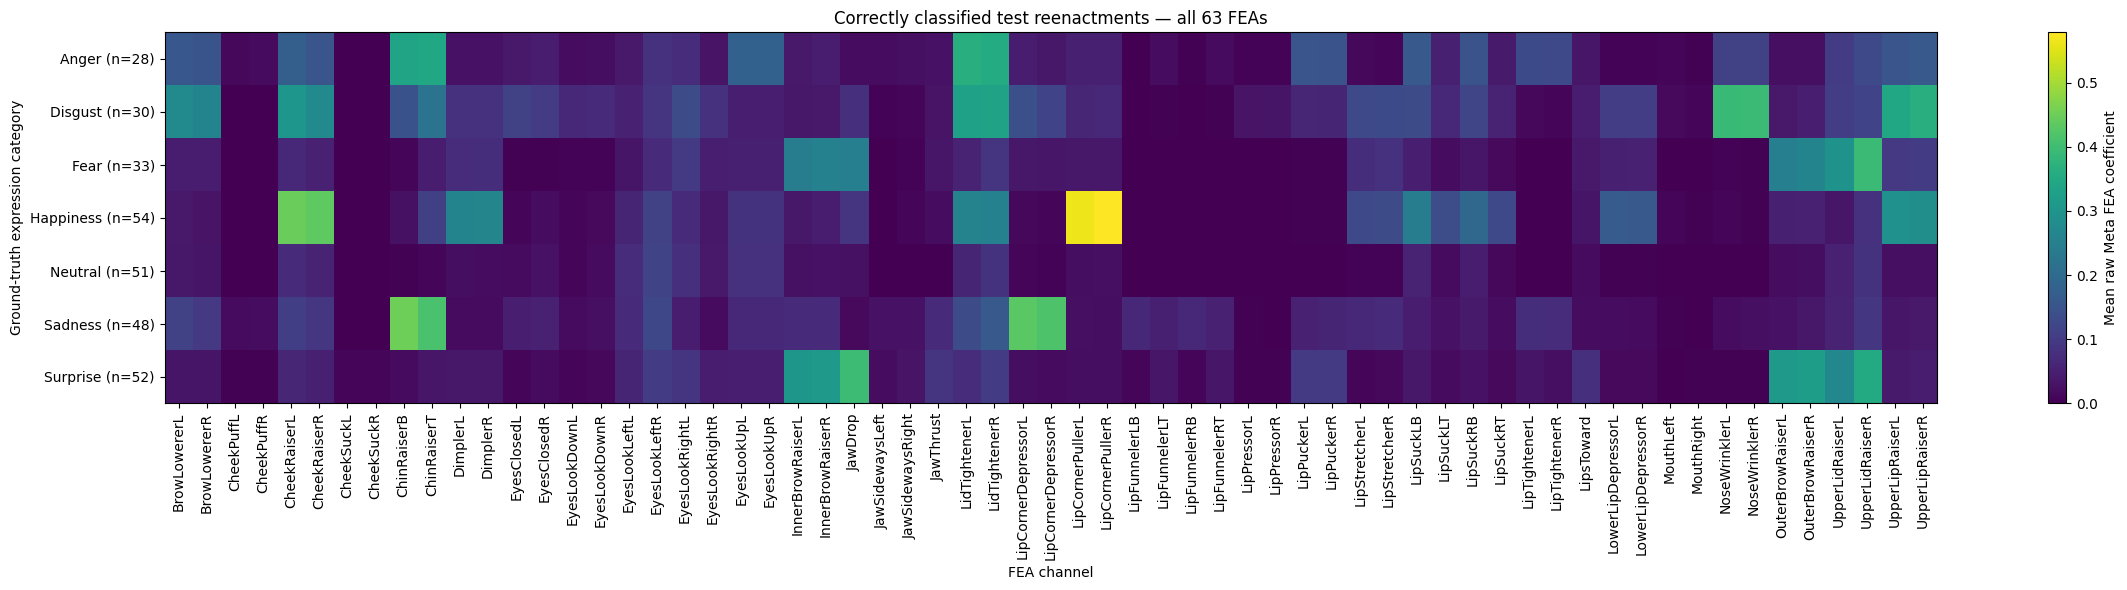

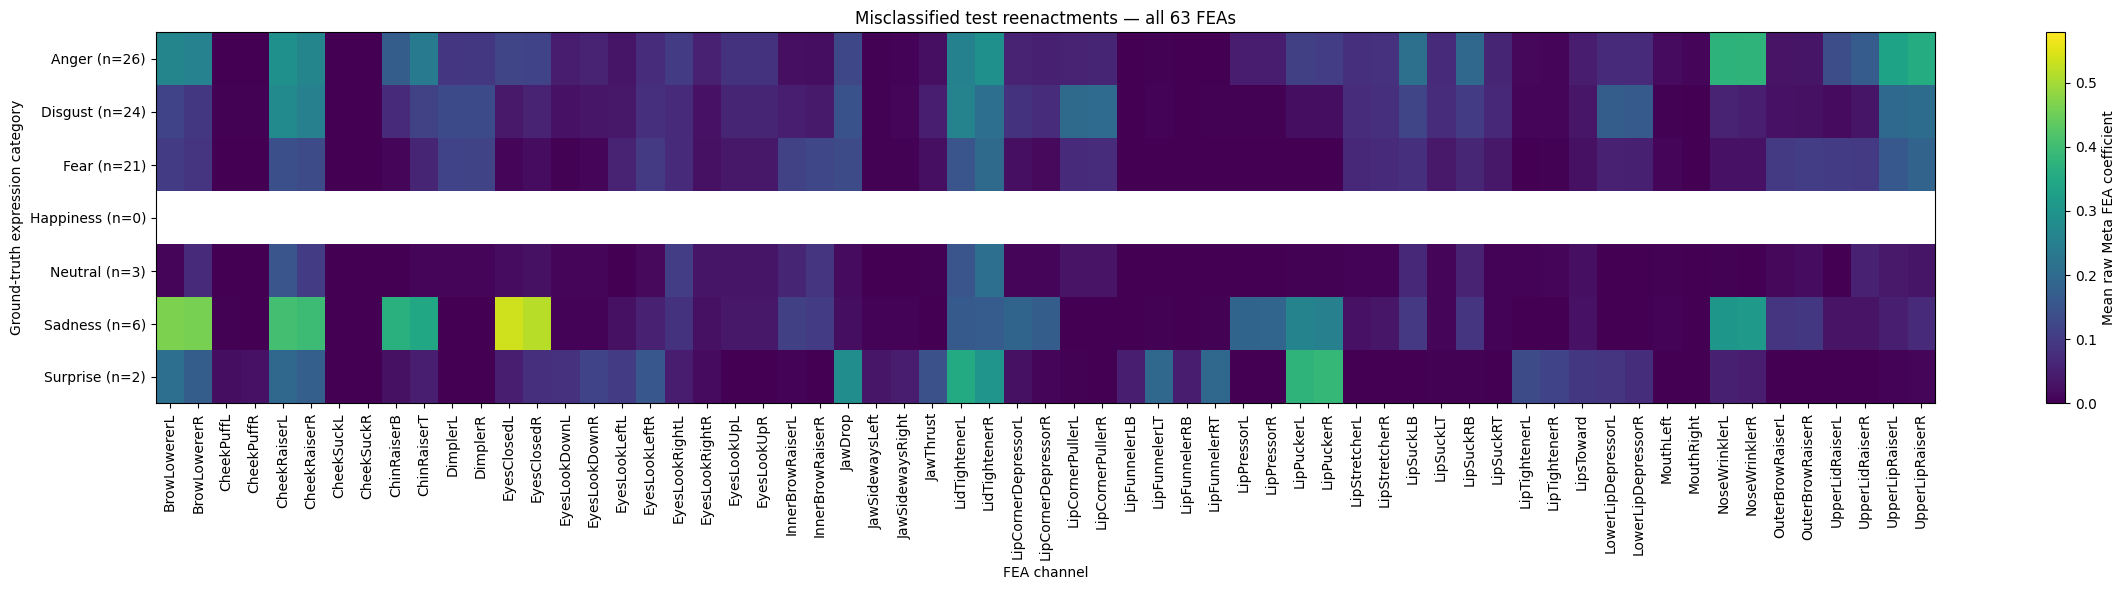

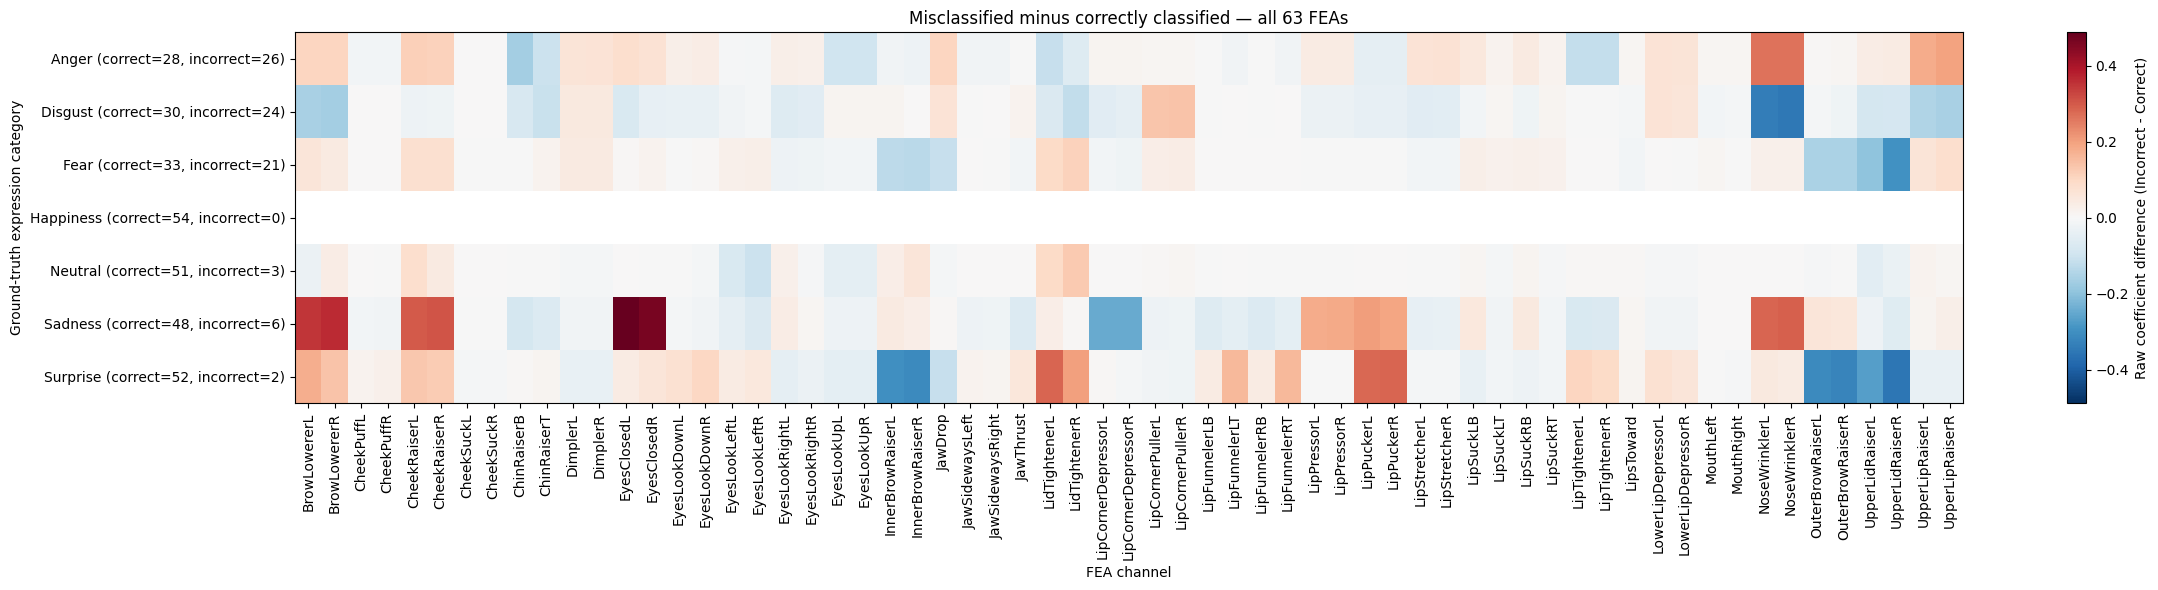

In [9]:
all_raw_vmax = float(
    np.nanmax(
        np.concatenate(
            [
                correct_profile_all.to_numpy().ravel(),
                incorrect_profile_all.to_numpy().ravel(),
            ]
        )
    )
)

save_heatmap(
    correct_profile_all,
    profile_row_labels(correct_profile_all, "Correct"),
    "Correctly classified test reenactments — all 63 FEAs",
    "Mean raw Meta FEA coefficient",
    "all_63_feas_correct_raw",
    figsize=(24, 6),
    vmin=0,
    vmax=all_raw_vmax,
)

save_heatmap(
    incorrect_profile_all,
    profile_row_labels(incorrect_profile_all, "Incorrect"),
    "Misclassified test reenactments — all 63 FEAs",
    "Mean raw Meta FEA coefficient",
    "all_63_feas_incorrect_raw",
    figsize=(24, 6),
    vmin=0,
    vmax=all_raw_vmax,
)

all_difference_limit = float(
    np.nanmax(np.abs(difference_profile_all.to_numpy()))
)

save_heatmap(
    difference_profile_all,
    difference_row_labels(),
    "Misclassified minus correctly classified — all 63 FEAs",
    "Raw coefficient difference (Incorrect - Correct)",
    "all_63_feas_incorrect_minus_correct_raw",
    figsize=(24, 6),
    vmin=-all_difference_limit,
    vmax=all_difference_limit,
)


## 10. Identify individual FEAs corresponding to the manuscript-relevant AUs

The manuscript's theoretical FACS table contains 20 unique AUs. Seventeen have a dedicated semantic FEA correspondence in the current mapping.

This section retains the **35 individual FEA channels** corresponding to those mapped AUs. It does not average left/right or multi-component channels into AU-level values.


In [10]:
paper_au_rows = pd.DataFrame(
    mapping["paper_table"]["au_to_fea"]
)

mapped_paper_aus = (
    paper_au_rows.loc[
        paper_au_rows["fea_count"] > 0
    ]
    .sort_values("au_number")
    .reset_index(drop=True)
)

missing_paper_aus = (
    paper_au_rows.loc[
        paper_au_rows["fea_count"] == 0
    ]
    .sort_values("au_number")
    .reset_index(drop=True)
)

paper_au_fea_pairs = []

for _, row in mapped_paper_aus.iterrows():
    fea_names = [
        name.strip()
        for name in row["fea_names"].split("|")
        if name.strip()
    ]

    for fea_name in fea_names:
        paper_au_fea_pairs.append({
            "au_code": row["au_code"],
            "au_name": row["au_name"],
            "fea_name": fea_name,
        })

paper_au_fea_pairs = pd.DataFrame(
    paper_au_fea_pairs
)

PAPER_AU_FEA_COLUMNS = (
    paper_au_fea_pairs["fea_name"].tolist()
)

assert len(PAPER_AU_FEA_COLUMNS) == 35
assert len(PAPER_AU_FEA_COLUMNS) == len(
    set(PAPER_AU_FEA_COLUMNS)
)
assert set(PAPER_AU_FEA_COLUMNS).issubset(
    set(FEA_COLUMNS)
)

paper_au_fea_pairs["heatmap_label"] = (
    paper_au_fea_pairs["au_code"]
    + " · "
    + paper_au_fea_pairs["fea_name"]
)

paper_au_fea_pairs.to_csv(
    OUTPUT_DIR / "paper_relevant_au_fea_channels.csv",
    index=False,
)

print(
    "Mapped manuscript AUs:",
    len(mapped_paper_aus),
)
print(
    "Individual corresponding FEA channels:",
    len(PAPER_AU_FEA_COLUMNS),
)

print("AUs without dedicated FEA correspondence:")
display(
    missing_paper_aus[
        [
            "au_code",
            "au_name",
            "paper_expression_categories",
        ]
    ]
)


Mapped manuscript AUs: 17
Individual corresponding FEA channels: 35
AUs without dedicated FEA correspondence:


,au_code,au_name,paper_expression_categories
0,AU11,Nasolabial Deepener,Sadness
1,AU25,Lips Part,Anger | Disgust | Fear | Sadness
2,AU27,Mouth Stretch,Fear | Surprise


## 11. Manuscript-relevant individual FEAs: Correct versus Incorrect

These focused heatmaps use the same raw sequence-mean values as the full 63-channel analysis, but display only individual FEA channels with a semantic correspondence to the AUs used in the manuscript's theoretical table.

These are likely the most directly interpretable model-error visualizations for the main paper or a compact supplement figure.


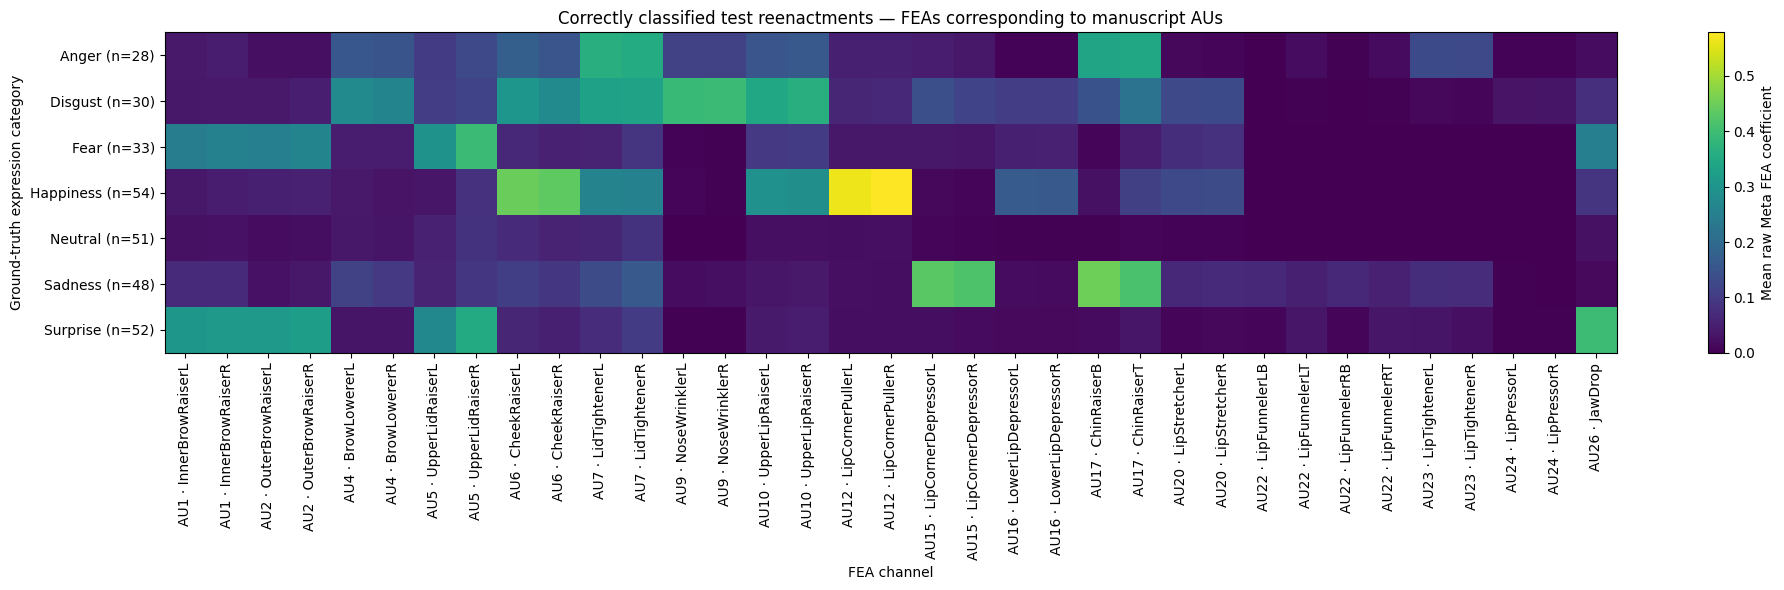

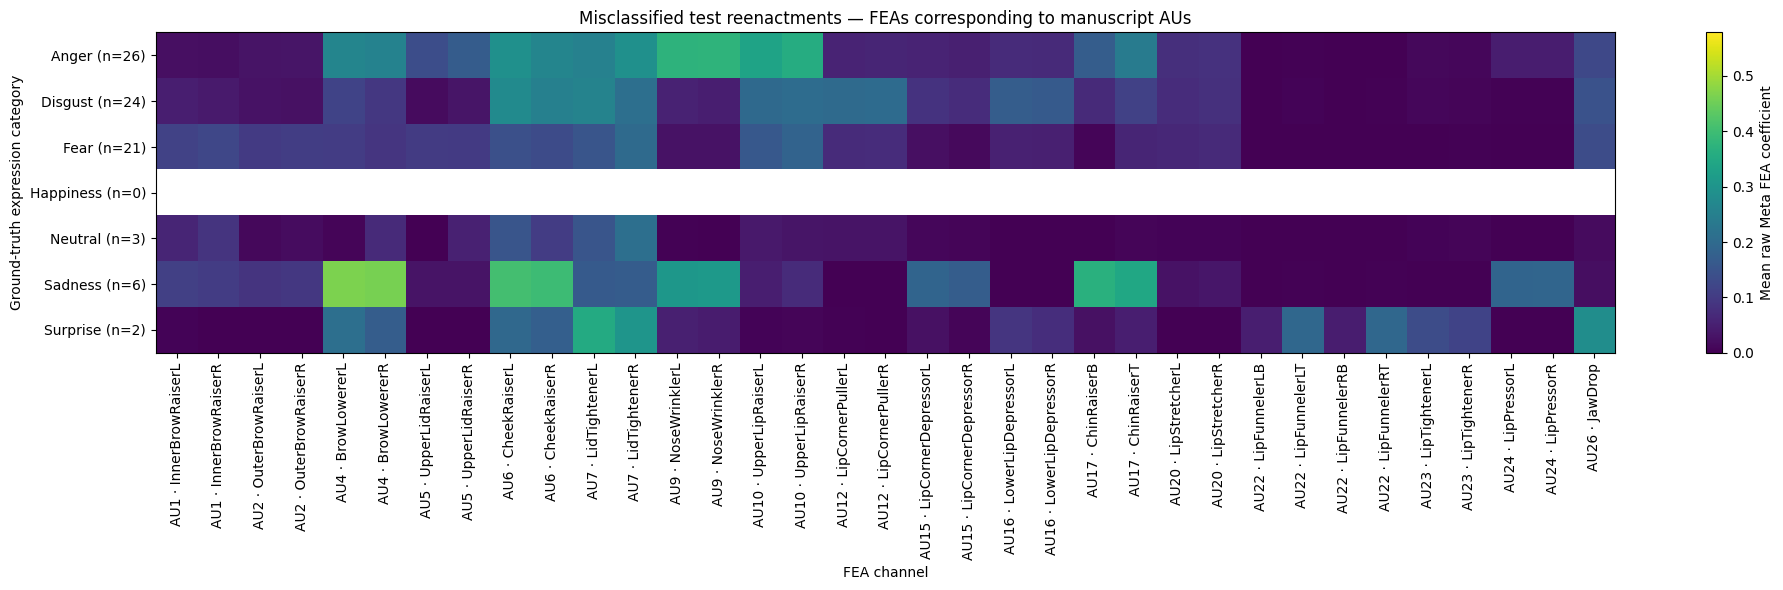

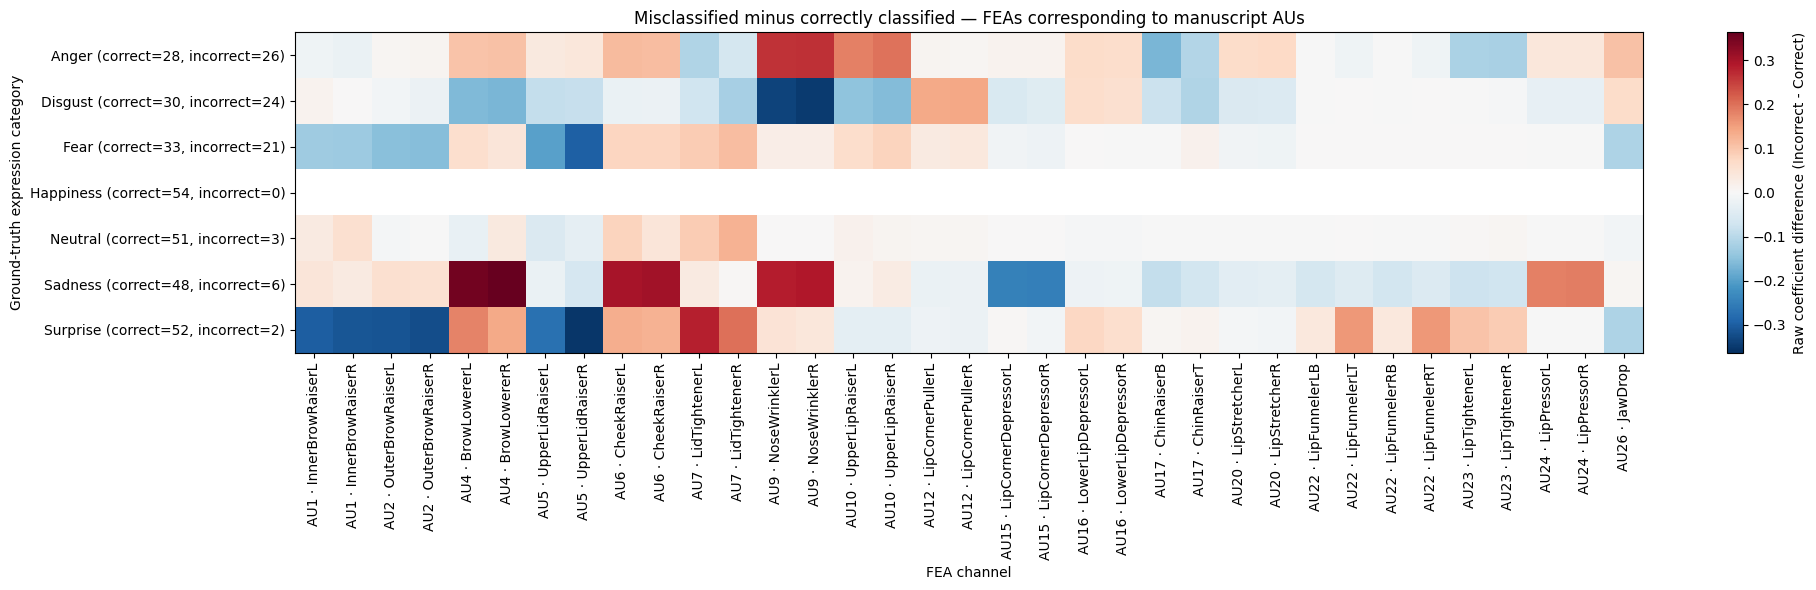

In [11]:
correct_profile_paper = (
    correct_profile_all[PAPER_AU_FEA_COLUMNS]
    .copy()
)

incorrect_profile_paper = (
    incorrect_profile_all[PAPER_AU_FEA_COLUMNS]
    .copy()
)

difference_profile_paper = (
    difference_profile_all[PAPER_AU_FEA_COLUMNS]
    .copy()
)

heatmap_labels = (
    paper_au_fea_pairs
    .set_index("fea_name")
    .loc[
        PAPER_AU_FEA_COLUMNS,
        "heatmap_label",
    ]
    .tolist()
)

correct_profile_paper.columns = heatmap_labels
incorrect_profile_paper.columns = heatmap_labels
difference_profile_paper.columns = heatmap_labels

paper_raw_vmax = float(
    np.nanmax(
        np.concatenate(
            [
                correct_profile_paper.to_numpy().ravel(),
                incorrect_profile_paper.to_numpy().ravel(),
            ]
        )
    )
)

save_heatmap(
    correct_profile_paper,
    profile_row_labels(correct_profile_paper, "Correct"),
    "Correctly classified test reenactments — FEAs corresponding to manuscript AUs",
    "Mean raw Meta FEA coefficient",
    "paper_relevant_feas_correct_raw",
    figsize=(20, 6),
    vmin=0,
    vmax=paper_raw_vmax,
)

save_heatmap(
    incorrect_profile_paper,
    profile_row_labels(
        incorrect_profile_paper,
        "Incorrect",
    ),
    "Misclassified test reenactments — FEAs corresponding to manuscript AUs",
    "Mean raw Meta FEA coefficient",
    "paper_relevant_feas_incorrect_raw",
    figsize=(20, 6),
    vmin=0,
    vmax=paper_raw_vmax,
)

paper_difference_limit = float(
    np.nanmax(
        np.abs(
            difference_profile_paper.to_numpy()
        )
    )
)

save_heatmap(
    difference_profile_paper,
    difference_row_labels(),
    "Misclassified minus correctly classified — FEAs corresponding to manuscript AUs",
    "Raw coefficient difference (Incorrect - Correct)",
    "paper_relevant_feas_incorrect_minus_correct_raw",
    figsize=(20, 6),
    vmin=-paper_difference_limit,
    vmax=paper_difference_limit,
)


## 12. Rank the strongest Correct–Incorrect differences

Raw coefficient differences are useful for direct interpretation, but different FEA channels have different marginal scales.

For cross-channel ranking only, the raw Correct–Incorrect difference is therefore also divided by the test-set standard deviation of the reenactment-level sequence mean:

$$
d^{(\mathrm{SD})}_{c,f}
=
\frac{
\bar{x}^{\mathrm{Incorrect}}_{c,f}
-
\bar{x}^{\mathrm{Correct}}_{c,f}
}{
s_f
}
$$

This is a descriptive SD-scaled mean difference, not a statistical significance test and not a model-importance score.


In [12]:
test_sequence_sd = (
    analysis_df[FEA_COLUMNS]
    .std(ddof=1).replace(0, np.nan)
)

sd_scaled_difference_all = (
    difference_profile_all / test_sequence_sd
)

difference_rank_rows = []

for category in CATEGORY_ORDER:
    n_incorrect = int(
        (
            (analysis_df["true_label"] == category)
            & ~analysis_df["correct"]
        ).sum()
    )

    if n_incorrect == 0:
        continue

    category_values = (
        sd_scaled_difference_all
        .loc[category]
        .dropna()
    )

    ranked_features = (
        category_values
        .abs()
        .sort_values(ascending=False)
        .index
    )

    for rank, fea_name in enumerate(
        ranked_features,
        start=1,
    ):
        difference_rank_rows.append({
            "true_label": category,
            "rank": rank,
            "fea_name": fea_name,
            "raw_difference_incorrect_minus_correct": float(
                difference_profile_all.loc[
                    category,
                    fea_name,
                ]
            ),
            "sd_scaled_difference": float(
                sd_scaled_difference_all.loc[
                    category,
                    fea_name,
                ]
            ),
            "abs_sd_scaled_difference": float(
                abs(
                    sd_scaled_difference_all.loc[
                        category,
                        fea_name,
                    ]
                )
            ),
            "is_paper_relevant_fea": (
                fea_name in PAPER_AU_FEA_COLUMNS
            ),
        })

difference_rankings = pd.DataFrame(
    difference_rank_rows
)

difference_rankings.to_csv(
    OUTPUT_DIR / "top_correct_incorrect_fea_differences.csv",
    index=False,
)

display(
    difference_rankings
    .groupby("true_label", sort=False)
    .head(5)
)


,true_label,rank,fea_name,raw_difference_incorrect_minus_correct,sd_scaled_difference,abs_sd_scaled_difference,is_paper_relevant_fea
0,Anger,1,LipTightenerR,-0.116555,-2.057406,2.057406,True
1,Anger,2,LipTightenerL,-0.116074,-1.969548,1.969548,True
2,Anger,3,NoseWrinklerL,0.263271,1.525112,1.525112,True
3,Anger,4,NoseWrinklerR,0.265559,1.515596,1.515596,True
4,Anger,5,CheekPuffR,-0.015031,-1.412298,1.412298,False
63,Disgust,1,NoseWrinklerR,-0.347165,-1.981337,1.981337,True
64,Disgust,2,NoseWrinklerL,-0.335479,-1.943405,1.943405,True
65,Disgust,3,BrowLowererR,-0.165948,-1.175310,1.175310,True
66,Disgust,4,MouthRight,-0.008285,-1.139595,1.139595,False
67,Disgust,5,BrowLowererL,-0.158944,-1.087461,1.087461,True


## 13. Focused rankings for manuscript-relevant FEA channels

This table makes it easier to interpret the focused AU-related heatmaps without mixing in unrelated eye-position or Action Descriptor channels.


In [13]:
paper_difference_rankings = (
    difference_rankings.loc[
        difference_rankings[
            "is_paper_relevant_fea"
        ]
    ]
    .copy()
)

paper_difference_rankings["rank_within_paper_relevant"] = (
    paper_difference_rankings
    .groupby("true_label")[
        "abs_sd_scaled_difference"
    ]
    .rank(
        method="first",
        ascending=False,
    )
    .astype(int)
)

paper_difference_rankings = (
    paper_difference_rankings
    .sort_values(
        [
            "true_label",
            "rank_within_paper_relevant",
        ]
    )
)

paper_difference_rankings.to_csv(
    OUTPUT_DIR / "top_correct_incorrect_paper_relevant_fea_differences.csv",
    index=False,
)

display(
    paper_difference_rankings
    .groupby("true_label", sort=False)
    .head(5)
)


,true_label,rank,fea_name,raw_difference_incorrect_minus_correct,sd_scaled_difference,abs_sd_scaled_difference,is_paper_relevant_fea,rank_within_paper_relevant
0,Anger,1,LipTightenerR,-0.116555,-2.057406,2.057406,True,1
1,Anger,2,LipTightenerL,-0.116074,-1.969548,1.969548,True,2
2,Anger,3,NoseWrinklerL,0.263271,1.525112,1.525112,True,3
3,Anger,4,NoseWrinklerR,0.265559,1.515596,1.515596,True,4
7,Anger,8,UpperLipRaiserR,0.196082,1.021990,1.021990,True,5
63,Disgust,1,NoseWrinklerR,-0.347165,-1.981337,1.981337,True,1
64,Disgust,2,NoseWrinklerL,-0.335479,-1.943405,1.943405,True,2
65,Disgust,3,BrowLowererR,-0.165948,-1.175310,1.175310,True,3
67,Disgust,5,BrowLowererL,-0.158944,-1.087461,1.087461,True,4
71,Disgust,9,UpperLipRaiserR,-0.158419,-0.825687,0.825687,True,5


## 14. Generate a concise Markdown report

The report records the sample counts, main error destinations, and the strongest descriptive differences between correctly and incorrectly classified reenactments.

Interpretation should remain conservative when a category has only a small number of misclassified reenactments.


In [14]:
def markdown_table(
    df,
    columns,
    n=None,
):
    table = df[columns].copy()

    if n is not None:
        table = table.head(n)

    def fmt(value):
        if isinstance(
            value,
            (float, np.floating),
        ):
            return f"{value:.4f}"

        return str(value).replace(
            "|",
            r"\|",
        )

    header = (
        "| "
        + " | ".join(columns)
        + " |"
    )
    separator = (
        "| "
        + " | ".join(
            ["---"] * len(columns)
        )
        + " |"
    )

    rows = [
        "| "
        + " | ".join(
            fmt(value)
            for value in row
        )
        + " |"
        for row in table.itertuples(
            index=False,
            name=None,
        )
    ]

    return "\n".join(
        [
            header,
            separator,
            *rows,
        ]
    )


def top_difference_text(
    rankings,
    n=5,
):
    parts = []

    for category in CATEGORY_ORDER:
        n_incorrect = int(
            (
                (analysis_df["true_label"] == category)
                & ~analysis_df["correct"]
            ).sum()
        )

        if n_incorrect == 0:
            parts.append(
                f"- **{category}:** no misclassified test reenactments; no Correct–Incorrect signal comparison is defined."
            )
            continue

        subset = (
            rankings.loc[
                rankings["true_label"] == category
            ]
            .head(n)
        )

        items = []

        for _, row in subset.iterrows():
            direction = (
                "higher in Incorrect"
                if row["sd_scaled_difference"] > 0
                else "lower in Incorrect"
            )

            items.append(
                f"{row['fea_name']} "
                f"(raw Δ={row['raw_difference_incorrect_minus_correct']:+.3f}, "
                f"SD-scaled Δ={row['sd_scaled_difference']:+.2f}; "
                f"{direction})"
            )

        parts.append(
            f"- **{category}:** "
            + "; ".join(items)
        )

    return "\n".join(parts)


count_report = (
    count_grid
    .reset_index()
)

confusion_report = (
    error_confusions
    .head(15)
)

report = f"""# FEA sequence model error patterns in the raw FEA signals

## Scope

This analysis compares the raw 30-step sequence-mean FEA profiles of correctly and incorrectly classified reenactments for the final FEA sequence model.

Only the held-out test set is used.

- Test reenactments: {len(analysis_df)}
- Correctly classified: {int(analysis_df['correct'].sum())}
- Misclassified: {int((~analysis_df['correct']).sum())}
- Accuracy: {accuracy:.4f}
- FEA channels: {len(FEA_COLUMNS)}
- Manuscript-relevant mapped individual FEA channels: {len(PAPER_AU_FEA_COLUMNS)}

The analysis is descriptive. Correct–Incorrect differences are not model-reliance or causal-importance measures.

## Correct and incorrect reenactments by ground-truth category

{markdown_table(count_report, ['true_label', 'Correct', 'Incorrect'])}

A category with no misclassified reenactments has no Incorrect raw-signal profile. Missing values are intentionally retained rather than replaced with zero.

## Most common FEA sequence model errors

{markdown_table(confusion_report, ['true_label', 'fea_pred', 'count'])}

These counts provide context for the Correct–Incorrect FEA comparisons. The heatmaps themselves remain grouped by **ground-truth category**.

## Primary raw-signal visualizations

### All 63 FEA channels

- `all_63_feas_correct_raw.png`
- `all_63_feas_incorrect_raw.png`
- `all_63_feas_incorrect_minus_correct_raw.png`

The Correct and Incorrect heatmaps use an identical raw-value scale.

### Individual FEAs corresponding to manuscript-relevant AUs

- `paper_relevant_feas_correct_raw.png`
- `paper_relevant_feas_incorrect_raw.png`
- `paper_relevant_feas_incorrect_minus_correct_raw.png`

These focused figures preserve all 35 individual FEA channels corresponding to the 17 manuscript AUs with a dedicated semantic FEA mapping. Left/right and multi-component channels are not averaged together.

## Strongest Correct–Incorrect differences among all FEAs

The values below compare sequence-mean coefficients within the same ground-truth category.

`raw Δ` is the raw Meta coefficient difference:

Incorrect minus Correct.

`SD-scaled Δ` divides that raw difference by the test-set standard deviation of the corresponding reenactment-level FEA summary and is used only to rank channels with different marginal scales.

{top_difference_text(difference_rankings, n=5)}

## Interpretation

A negative difference means that a coefficient is weaker on average among misclassified reenactments of that true category. A positive difference means that it is stronger.

These differences can identify signal characteristics associated with successful or unsuccessful recognition. For example, if a category's most characteristic FEA channels are systematically weaker among its errors, that would suggest that the misclassified reenactments contain a less pronounced version of the dataset-level category pattern.

Conversely, if misclassified reenactments show stronger coefficients associated with another category, that may motivate a targeted confusion analysis.

However, the present analysis cannot establish that the FEA sequence model actually depends on those coefficients. That question requires the separate model-perturbation analysis.

## Sample-size caution

Correct and Incorrect groups are not equally sized. Some expression categories have only a small number of model errors, and a category may have no errors at all.

Therefore:

- always report the group sizes shown in the heatmap row labels;
- interpret small Incorrect groups cautiously;
- do not infer statistical significance from visual differences;
- consult the directed confusion analysis below, including its sample and participant counts.

## Recommended figure use

The focused raw heatmaps for the 35 individual FEAs corresponding to the manuscript-relevant AUs are the most compact error-analysis figures for potential use in the paper or supplement.

The complete 63-channel Correct, Incorrect, and difference heatmaps should be retained in the supplementary analysis for transparency.

The difference heatmaps are particularly useful for analysis because they directly show the direction and magnitude of Correct–Incorrect signal changes, but the paired Correct/Incorrect raw heatmaps remain easier to interpret on the original Meta coefficient scale.
"""

report_path = (
    OUTPUT_DIR
    / "fea_sequence_model_error_patterns_report.md"
)

report_path.write_text(
    report,
    encoding="utf-8",
)

print(report)
print("\nSaved:", report_path)


# FEA sequence model error patterns in the raw FEA signals

## Scope

This analysis compares the raw 30-step sequence-mean FEA profiles of correctly and incorrectly classified reenactments for the final FEA sequence model.

Only the held-out test set is used.

- Test reenactments: 378
- Correctly classified: 296
- Misclassified: 82
- Accuracy: 0.7831
- FEA channels: 63
- Manuscript-relevant mapped individual FEA channels: 35

The analysis is descriptive. Correct–Incorrect differences are not model-reliance or causal-importance measures.

## Correct and incorrect reenactments by ground-truth category

| true_label | Correct | Incorrect |
| --- | --- | --- |
| Anger | 28 | 26 |
| Disgust | 30 | 24 |
| Fear | 33 | 21 |
| Happiness | 54 | 0 |
| Neutral | 51 | 3 |
| Sadness | 48 | 6 |
| Surprise | 52 | 2 |

A category with no misclassified reenactments has no Incorrect raw-signal profile. Missing values are intentionally retained rather than replaced with zero.

## Most common FEA sequence 

## 15. Directed confusion analysis: scope and reference groups

We now separate specific destinations (e.g., true Anger → predicted Disgust) instead of pooling all errors of a true category. Trajectories are intentionally deferred.

Selection: retain Anger–Disgust and Fear–Surprise; include Disgust–Happiness when observed; also include the five most frequent **unordered** error pairs (both directions summed, including ties at the fifth rank). Five is a display selection, not an activation or significance threshold. The full directed confusion table remains available. This is an exploratory, test-set descriptive analysis, not an additional model-selection step.

For each pair, show six raw mean profiles: all A, correct A, A→B, all B, correct B, B→A. The primary error contrast is **A→B minus correctly classified A**; compare the same errors with correct B and with both all-class profiles as context. An all-A reference includes A→B itself, so it is not an independent comparison and attenuates the contrast. Correct-only references are also selected subsets, not pure class prototypes.

All comparisons retain individual channels (63 and the focused 35); semantic AU-related group means are an additional interpretation aid. Every mean is sample-weighted, after averaging each 30-step sequence. Raw scales are fixed at [0,1]. Difference plots use a common symmetric scale and a diverging palette. Empty subsets remain NaN, never zero.

Ranks do not establish feature separation or equivalence. We therefore also show actual sample distributions, group SDs, and quartiles, and report participant coverage. A same-participant sensitivity check compares error and correct means only within participants who supply both subsets, then weights these participants equally. It can differ from the primary result and does not remove all confounding.

In [15]:
PAIR_DIR = OUTPUT_DIR / "confusion_pairs"
PAIR_DIR.mkdir(exist_ok=True)
TOP_N_PAIRS = 5
pair_counts = error_confusions.copy()
pair_counts['pair'] = [tuple(sorted((a, b))) for a, b in zip(pair_counts.true_label, pair_counts.fea_pred)]
pair_counts = pair_counts.groupby('pair')['count'].sum().sort_values(ascending=False)
cutoff = pair_counts.iloc[min(TOP_N_PAIRS, len(pair_counts)) - 1] if len(pair_counts) else np.inf
selected_pairs = [('Anger', 'Disgust'), ('Fear', 'Surprise')]
if pair_counts.get(tuple(sorted(('Disgust', 'Happiness'))), 0) > 0:
    selected_pairs.append(('Disgust', 'Happiness'))
for pair in pair_counts[pair_counts >= cutoff].index:
    if frozenset(pair) not in [frozenset(p) for p in selected_pairs]:
        selected_pairs.append(pair)

pair_selection = pd.DataFrame([
    {'class_a': a, 'class_b': b, 'errors_both_directions': int(pair_counts.get(tuple(sorted((a,b))), 0))}
    for a,b in selected_pairs
])
pair_selection.to_csv(PAIR_DIR / 'selected_pairs.csv', index=False)
display(pair_selection)

# AU-related groups only, all available mapped AUs (not just Table 1).
AU_MEMBERS = {k: v['fea_names'] for k,v in mapping['facs_to_fea'].items()
              if v['facs_kind'] == 'AU' and v['fea_names']}
AU_MEMBERS = dict(sorted(AU_MEMBERS.items(), key=lambda kv: int(kv[0][2:])))
AU_COLUMNS = list(AU_MEMBERS)
for au, members in AU_MEMBERS.items():
    assert set(members).issubset(FEA_COLUMNS)
    analysis_df[au] = analysis_df[members].mean(axis=1)
AU_LABELS = {au: au + ' · ' + mapping['facs_to_fea'][au]['facs_name'] for au in AU_COLUMNS}
ALL_MEASURES = FEA_COLUMNS + AU_COLUMNS
reference_sd = analysis_df[ALL_MEASURES].std(ddof=1).replace(0, np.nan)

pair_subsets = {}
coverage_rows = []
participant_rows = []
profile_rows = []
sample_rows = []
for a,b in selected_pairs:
    pair_name = f'{a}__{b}'
    subsets = {
        f'{a}: all': analysis_df.loc[analysis_df.true_label.eq(a)],
        f'{a}: correct': analysis_df.loc[analysis_df.true_label.eq(a) & analysis_df.correct],
        f'{a} → {b}': analysis_df.loc[analysis_df.true_label.eq(a) & analysis_df.fea_pred.eq(b)],
        f'{b}: all': analysis_df.loc[analysis_df.true_label.eq(b)],
        f'{b}: correct': analysis_df.loc[analysis_df.true_label.eq(b) & analysis_df.correct],
        f'{b} → {a}': analysis_df.loc[analysis_df.true_label.eq(b) & analysis_df.fea_pred.eq(a)],
    }
    pair_subsets[pair_name] = subsets
    for label, subset in subsets.items():
        coverage_rows.append(dict(pair=pair_name, subset=label, n=len(subset), participants=subset.participant_id.nunique()))
        for pid, count in subset.groupby('participant_id').size().items():
            participant_rows.append(dict(pair=pair_name, subset=label, participant_id=pid, n=count))
        for feature in ALL_MEASURES:
            values = subset[feature]
            profile_rows.append(dict(pair=pair_name, subset=label, feature=feature,
                mean=values.mean(), sd=values.std(ddof=1), q25=values.quantile(.25),
                median=values.median(), q75=values.quantile(.75), n=len(values)))
        if ' → ' in label:
            sample_rows.append(subset[['reenactment_id','participant_id','true_label','fea_pred'] + FEA_COLUMNS].assign(pair=pair_name))
coverage = pd.DataFrame(coverage_rows)
participant_coverage = pd.DataFrame(participant_rows)
pair_profiles = pd.DataFrame(profile_rows)
coverage.to_csv(PAIR_DIR / 'subset_counts.csv', index=False)
participant_coverage.to_csv(PAIR_DIR / 'participant_counts.csv', index=False)
pair_profiles.to_csv(PAIR_DIR / 'raw_profiles_and_distributions.csv', index=False)
pd.concat(sample_rows, ignore_index=True).to_csv(PAIR_DIR / 'confused_sample_sequence_means.csv', index=False)
display(coverage)

,class_a,class_b,errors_both_directions
0,Anger,Disgust,25
1,Fear,Surprise,9
2,Disgust,Happiness,10
3,Disgust,Fear,10
4,Disgust,Sadness,6
5,Fear,Neutral,6


,pair,subset,n,participants
0,Anger__Disgust,Anger: all,54,8
1,Anger__Disgust,Anger: correct,28,6
2,Anger__Disgust,Anger → Disgust,23,5
3,Anger__Disgust,Disgust: all,54,8
4,Anger__Disgust,Disgust: correct,30,7
5,Anger__Disgust,Disgust → Anger,2,2
6,Fear__Surprise,Fear: all,54,8
7,Fear__Surprise,Fear: correct,33,6
8,Fear__Surprise,Fear → Surprise,8,3
9,Fear__Surprise,Surprise: all,54,8


## 16. Contrasts, class differences, and same-participant sensitivity

For every directed error group E = A→B, export E−correct A, E−all A, E−correct B, and E−all B, in raw coefficient units and divided by the **same full-test reenactment SD per channel/group**. This is not Cohen's d or a significance test.

For every pair, additionally rank class differences using correct-only and all-class references. Small mean differences do not prove overlapping distributions; SDs, quartiles, and sample plots provide the complementary view. The tables use continuous differences and no binary separation threshold.

The same-participant check estimates mean(E_p−correct A_p) over participants with both groups. Its participant count can be small or zero. The primary and sensitivity estimates describe different populations and weighting schemes.

In [16]:
contrast_rows = []
class_rows = []
for a,b in selected_pairs:
    pair = f'{a}__{b}'
    subsets = pair_subsets[pair]
    for source,target in [(a,b),(b,a)]:
        errors = subsets[f'{source} → {target}']
        correct = subsets[f'{source}: correct']
        ep = errors.groupby('participant_id')[ALL_MEASURES].mean()
        cp = correct.groupby('participant_id')[ALL_MEASURES].mean()
        common = ep.index.intersection(cp.index)
        within = ep.loc[common] - cp.loc[common]
        within.to_csv(PAIR_DIR / f'{source}_to_{target}_within_participant_deltas.csv')
        for reference in [f'{source}: correct',f'{source}: all',f'{target}: correct',f'{target}: all']:
            ref = subsets[reference]
            for feature in ALL_MEASURES:
                delta = errors[feature].mean() - ref[feature].mean()
                own_correct = reference == f'{source}: correct'
                contrast_rows.append(dict(pair=pair, source=source, target=target, reference=reference,
                    feature=feature, kind='FEA' if feature in FEA_COLUMNS else 'AU-related group',
                    n_error=len(errors), n_reference=len(ref), participants_error=errors.participant_id.nunique(),
                    error_mean=errors[feature].mean(), reference_mean=ref[feature].mean(),
                    raw_delta=delta, sd_scaled_delta=delta/reference_sd[feature],
                    shared_participants=len(common) if own_correct else np.nan,
                    within_participant_delta=within[feature].mean() if own_correct else np.nan,
                    within_participant_positive=int(within[feature].gt(0).sum()) if own_correct else np.nan,
                    within_participant_negative=int(within[feature].lt(0).sum()) if own_correct else np.nan))
    for basis in ['all', 'correct']:
        av = subsets[f'{a}: {basis}']; bv = subsets[f'{b}: {basis}']
        for feature in ALL_MEASURES:
            delta = bv[feature].mean() - av[feature].mean()
            class_rows.append(dict(pair=pair, basis=basis, feature=feature,
                kind='FEA' if feature in FEA_COLUMNS else 'AU-related group',
                a_mean=av[feature].mean(), b_mean=bv[feature].mean(),
                a_sd=av[feature].std(ddof=1), b_sd=bv[feature].std(ddof=1),
                raw_delta_b_minus_a=delta, sd_scaled_delta=delta/reference_sd[feature]))
contrasts = pd.DataFrame(contrast_rows)
contrasts['abs_sd_delta'] = contrasts.sd_scaled_delta.abs()
class_differences = pd.DataFrame(class_rows)
class_differences['abs_sd_delta'] = class_differences.sd_scaled_delta.abs()
contrasts.to_csv(PAIR_DIR / 'all_directed_contrasts.csv', index=False)
class_differences.to_csv(PAIR_DIR / 'class_reference_differences.csv', index=False)
primary_contrasts = contrasts.loc[contrasts.reference.eq(contrasts.source + ': correct')].copy()
primary_contrasts = primary_contrasts.sort_values('abs_sd_delta', ascending=False, na_position='last')
display(primary_contrasts.loc[primary_contrasts.kind.eq('FEA')].groupby(['pair','source'], sort=False).head(5)[
    ['source','target','n_error','feature','error_mean','reference_mean','raw_delta','sd_scaled_delta','shared_participants','within_participant_delta']])

,source,target,n_error,feature,error_mean,reference_mean,raw_delta,sd_scaled_delta,shared_participants,within_participant_delta
3072,Sadness,Disgust,4,EyesClosedL,7.452994e-01,0.048194,0.697105,6.432723,1.0,0.351718
3099,Sadness,Disgust,4,LipPressorR,2.817075e-01,0.002060,0.279647,6.265325,1.0,0.235796
3073,Sadness,Disgust,4,EyesClosedR,7.138029e-01,0.053751,0.660052,6.255080,1.0,0.328953
3098,Sadness,Disgust,4,LipPressorL,2.800364e-01,0.004360,0.275676,6.222014,1.0,0.233919
2433,Fear,Disgust,3,MouthLeft,6.020438e-02,0.001432,0.058772,4.925000,1.0,-0.000114
3061,Sadness,Disgust,4,BrowLowererR,6.885464e-01,0.097189,0.591357,4.188230,1.0,0.363147
342,Disgust,Anger,2,CheekPuffL,3.625086e-02,0.001196,0.035054,3.689794,2.0,0.035460
343,Disgust,Anger,2,CheekPuffR,3.624324e-02,0.001564,0.034679,3.258443,2.0,0.035454
2775,Disgust,Sadness,2,NoseWrinklerL,4.283276e-03,0.389908,-0.385624,-2.233897,1.0,-0.342064
2776,Disgust,Sadness,2,NoseWrinklerR,6.599496e-03,0.394997,-0.388398,-2.216658,1.0,-0.356847


## 17. Raw profiles and directed-difference heatmaps

Each pair is shown for all 63 channels, the 35 Table-1-related individual channels, and the semantic AU-related groups. Row labels include sample and participant counts. AU labels indicate semantic correspondence, not measured FACS activity.

The signed difference panels contain A→B−correct A and B→A−correct B. A single global symmetric difference scale is used across all new pairs and representations. Gray means unavailable; a zero difference remains an actual zero.

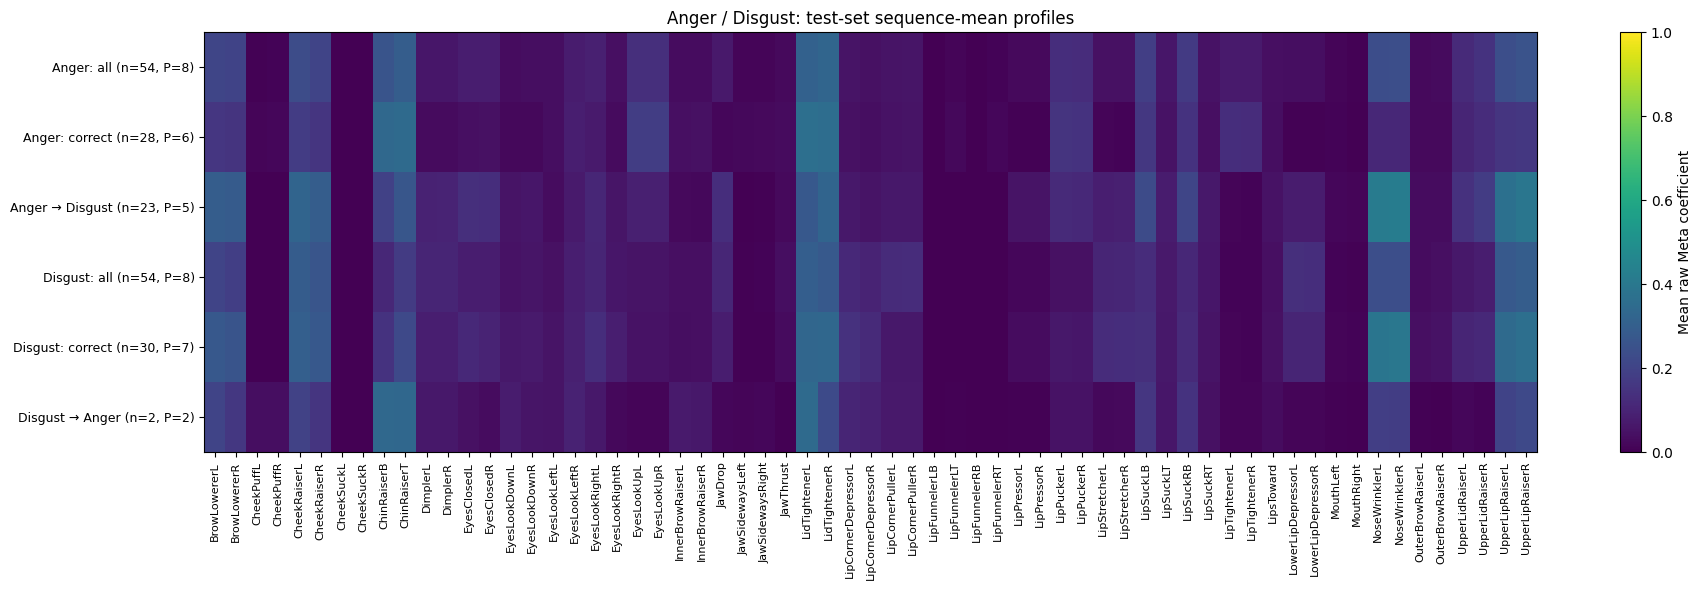

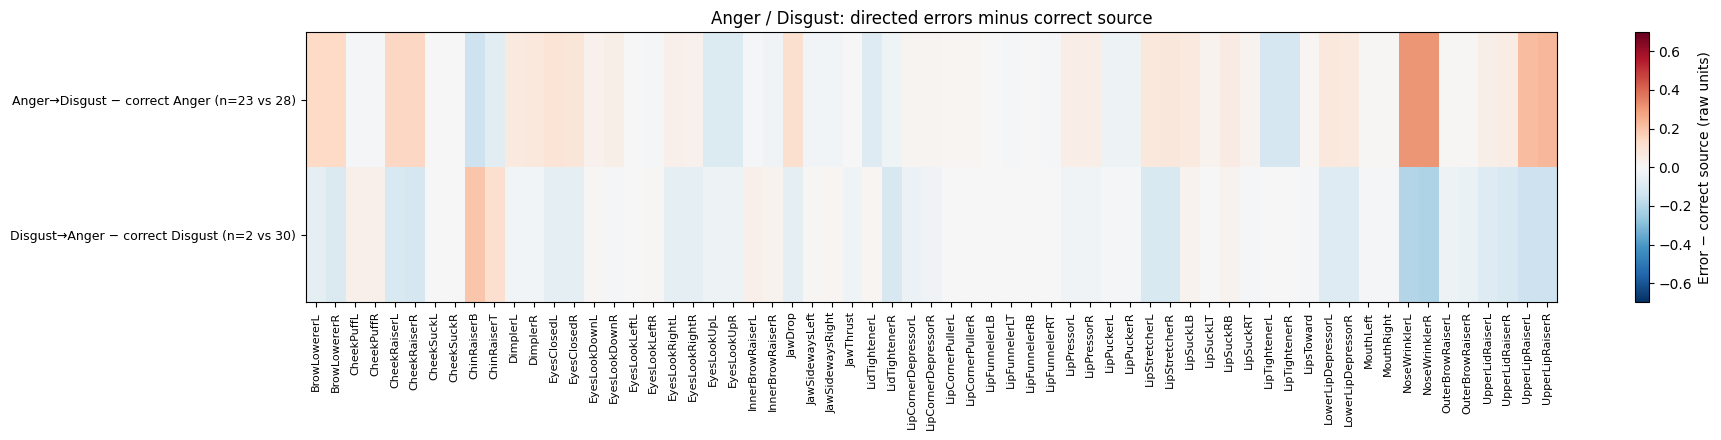

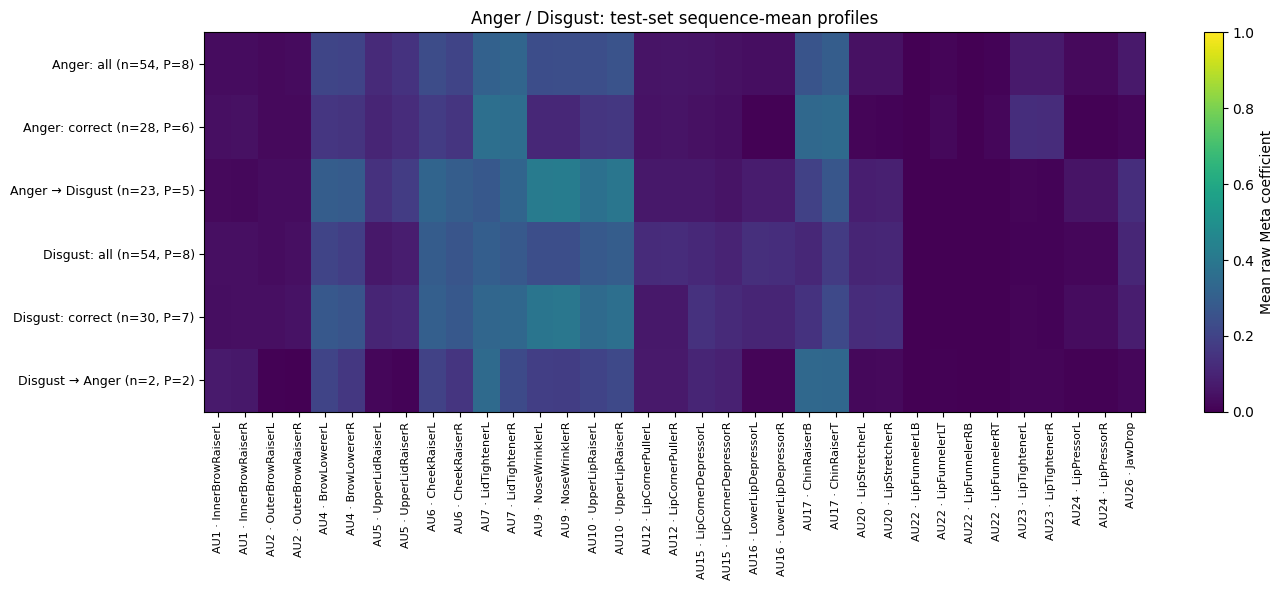

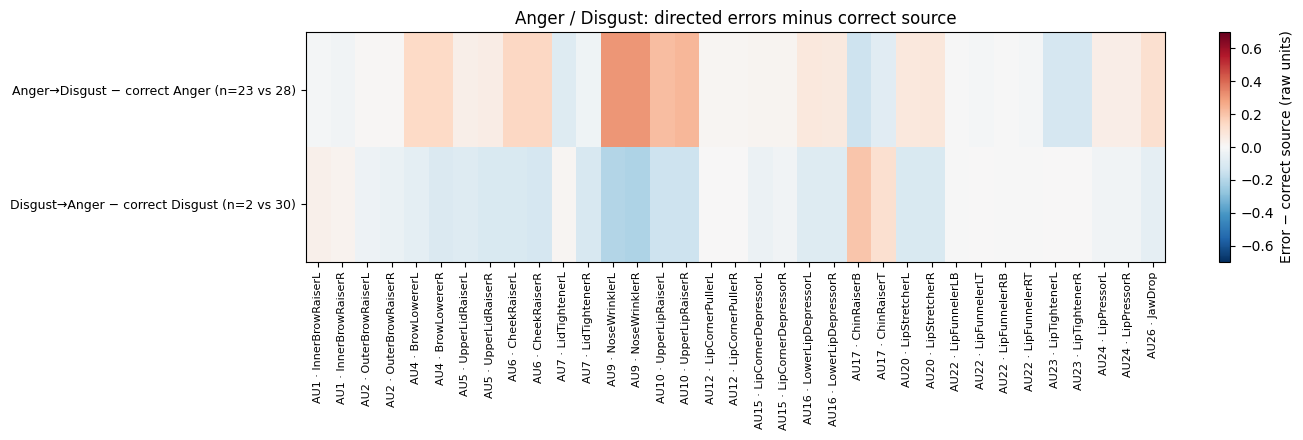

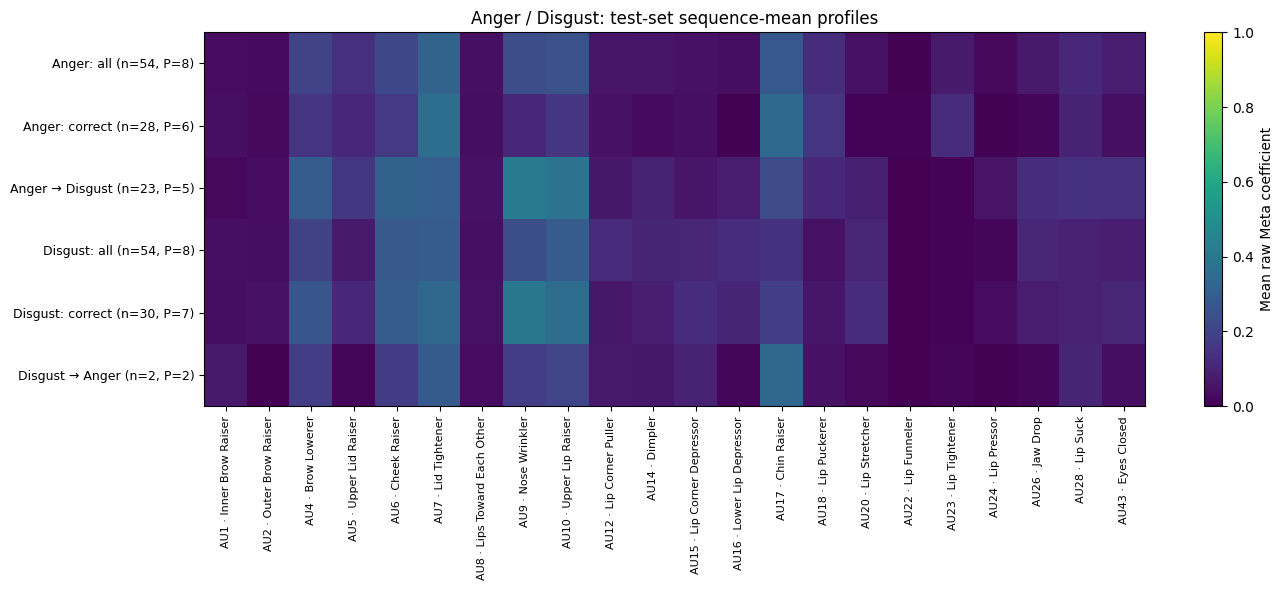

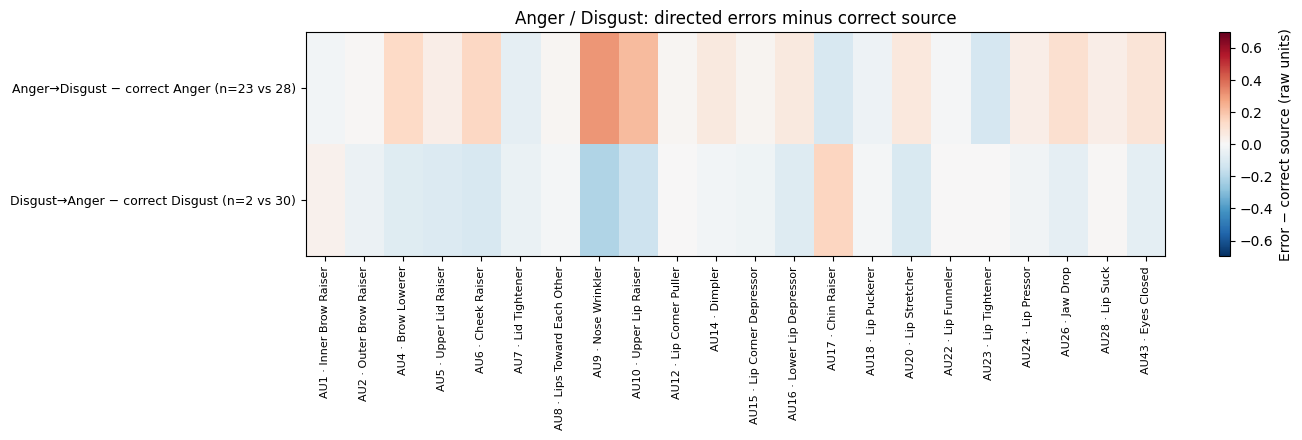

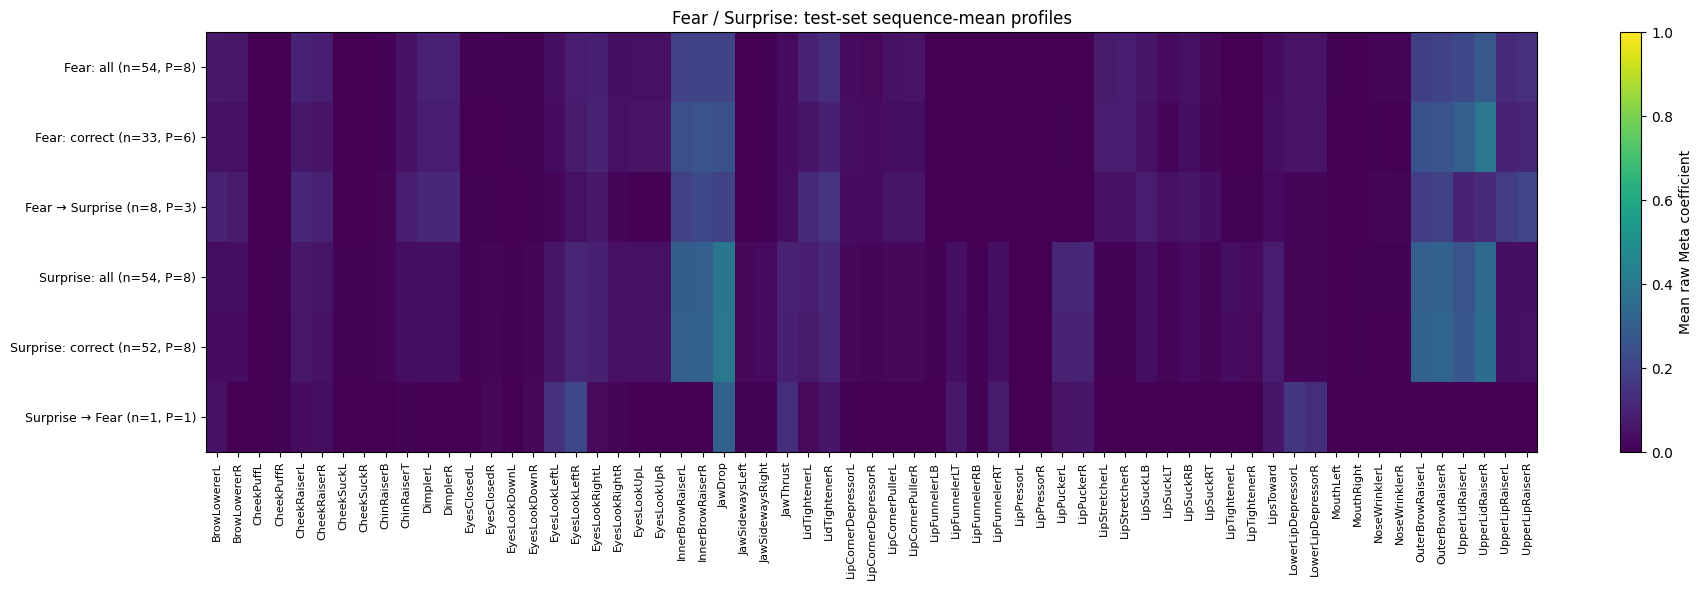

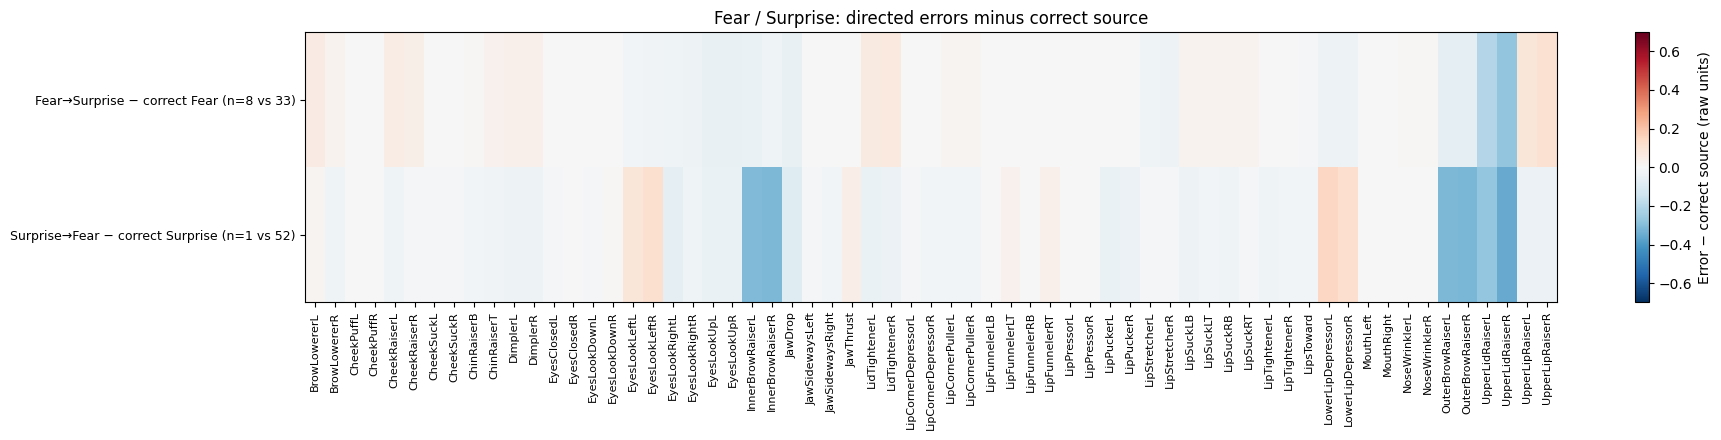

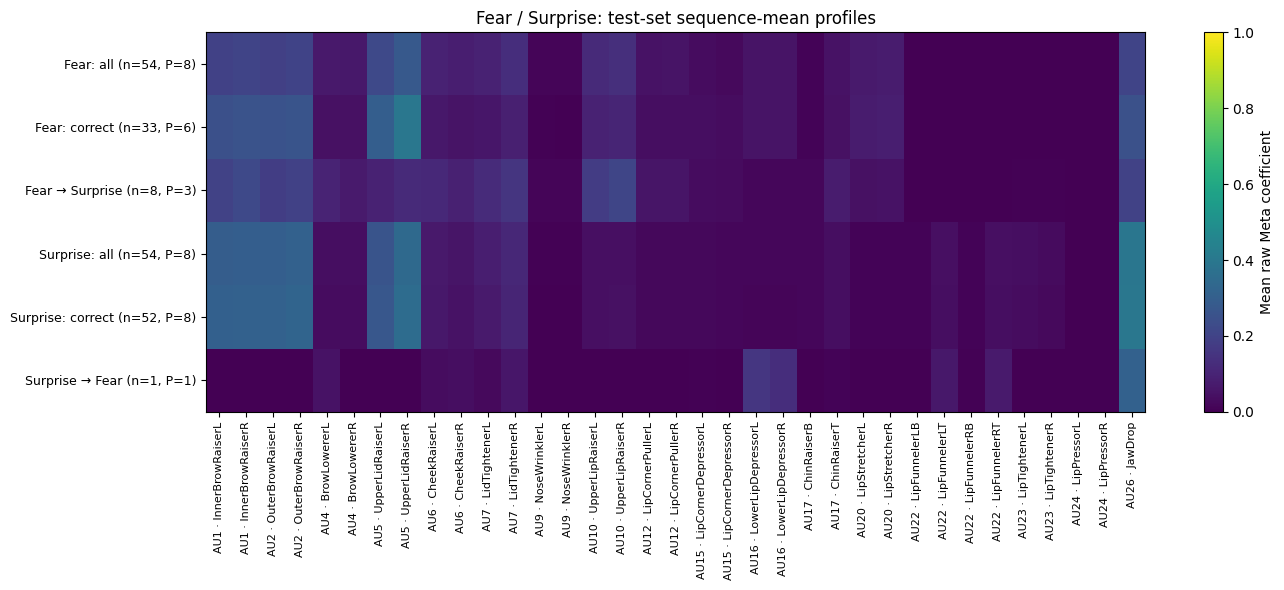

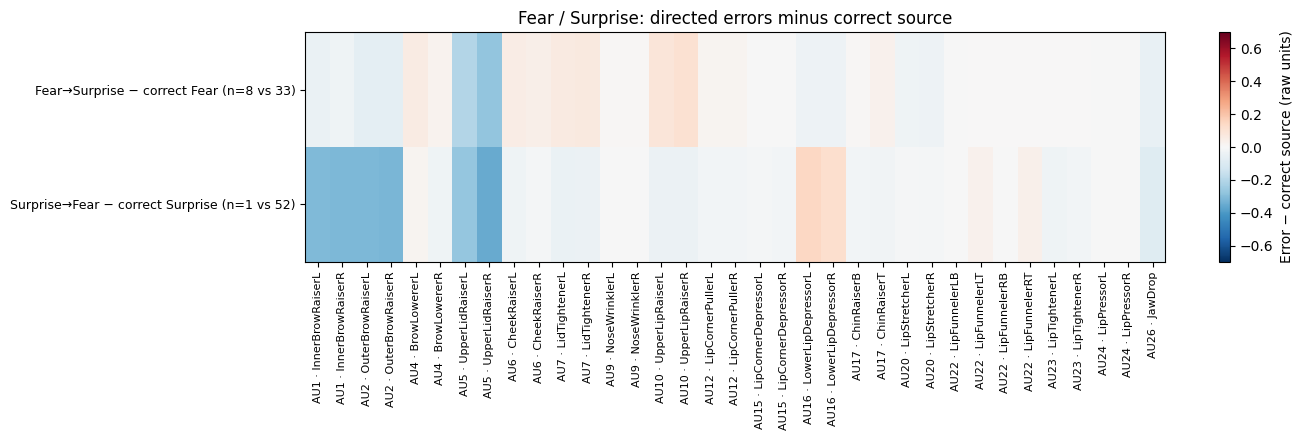

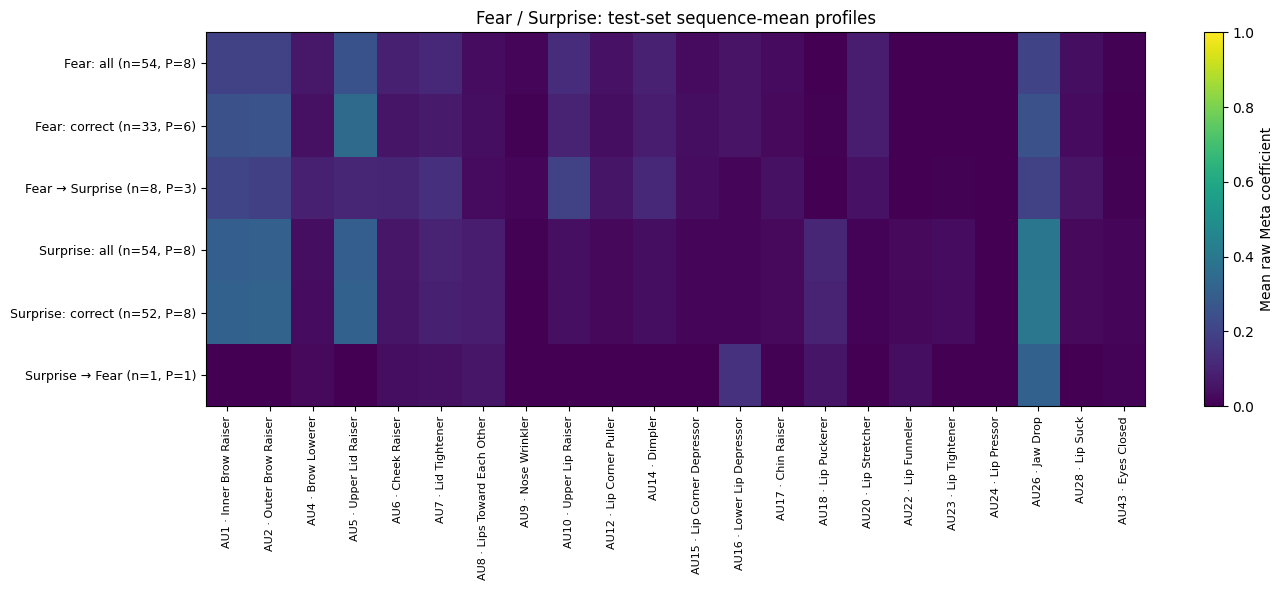

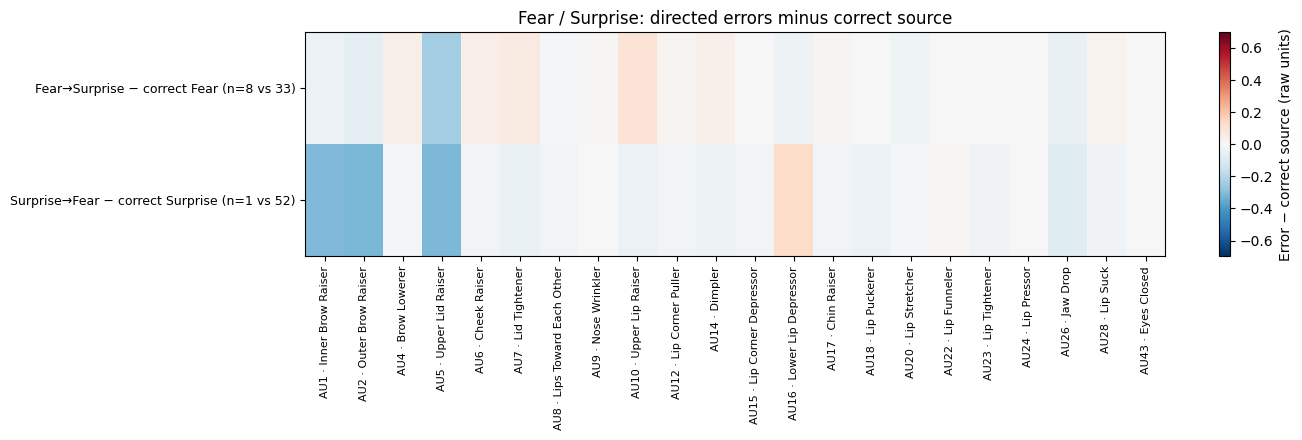

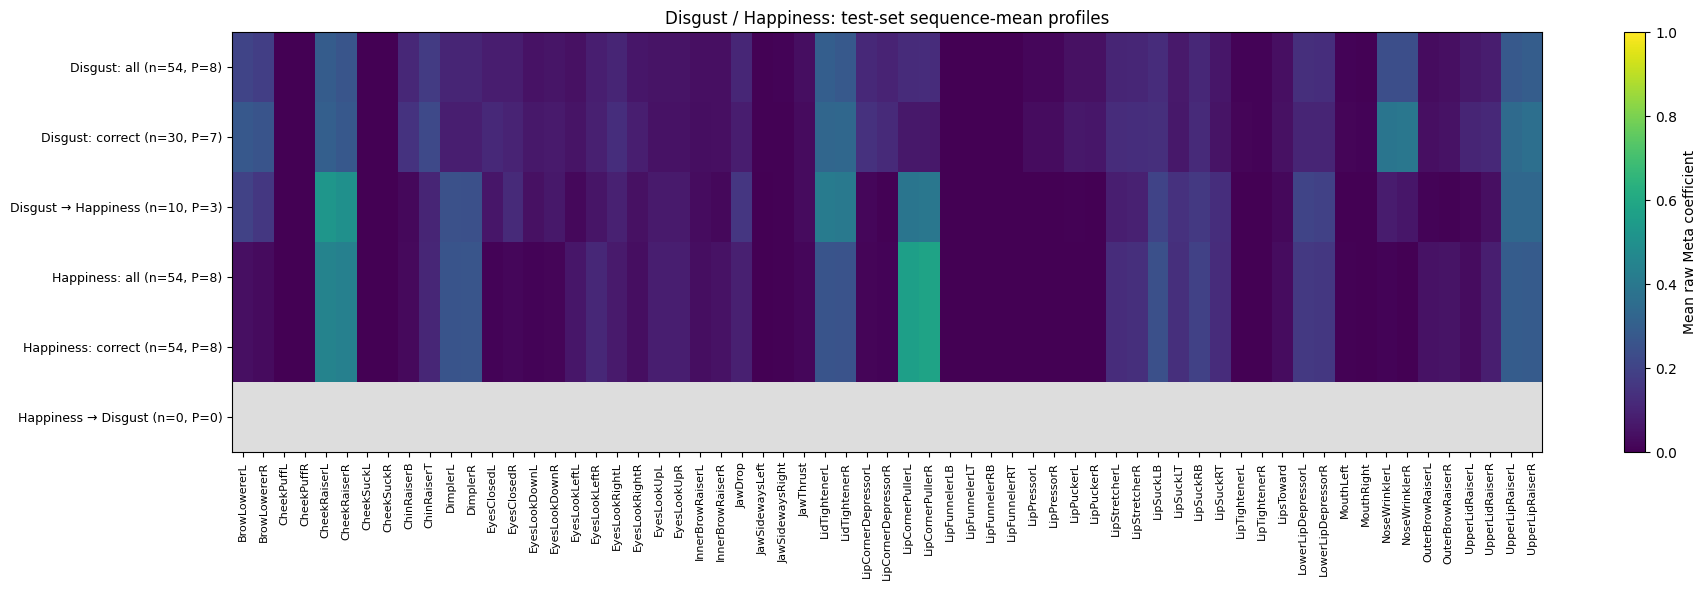

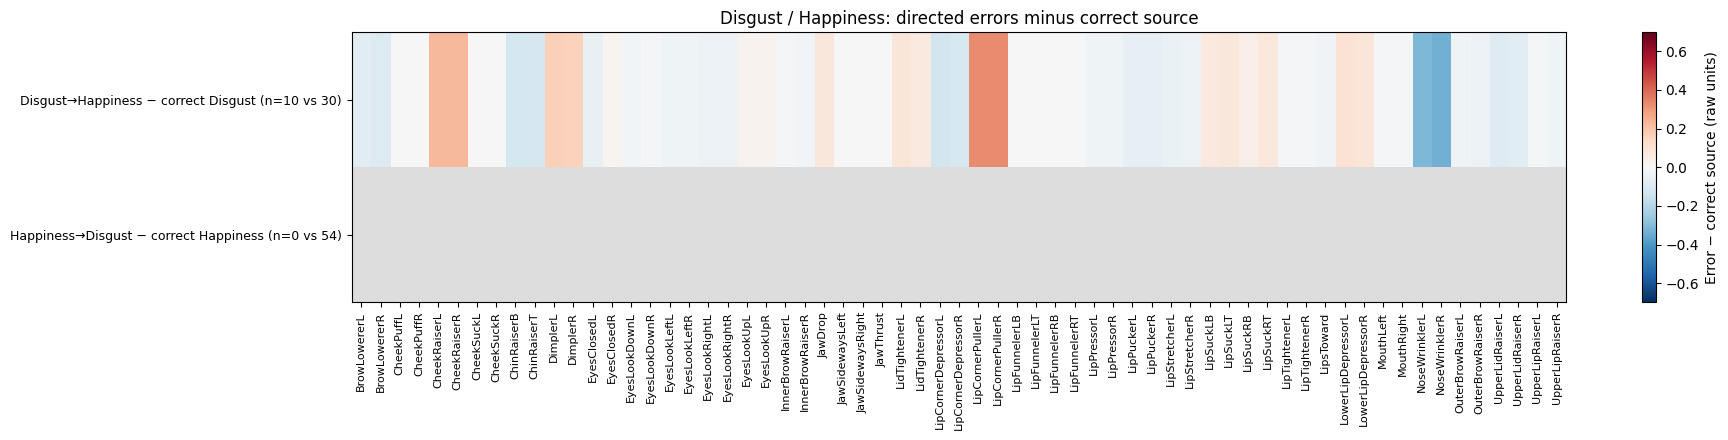

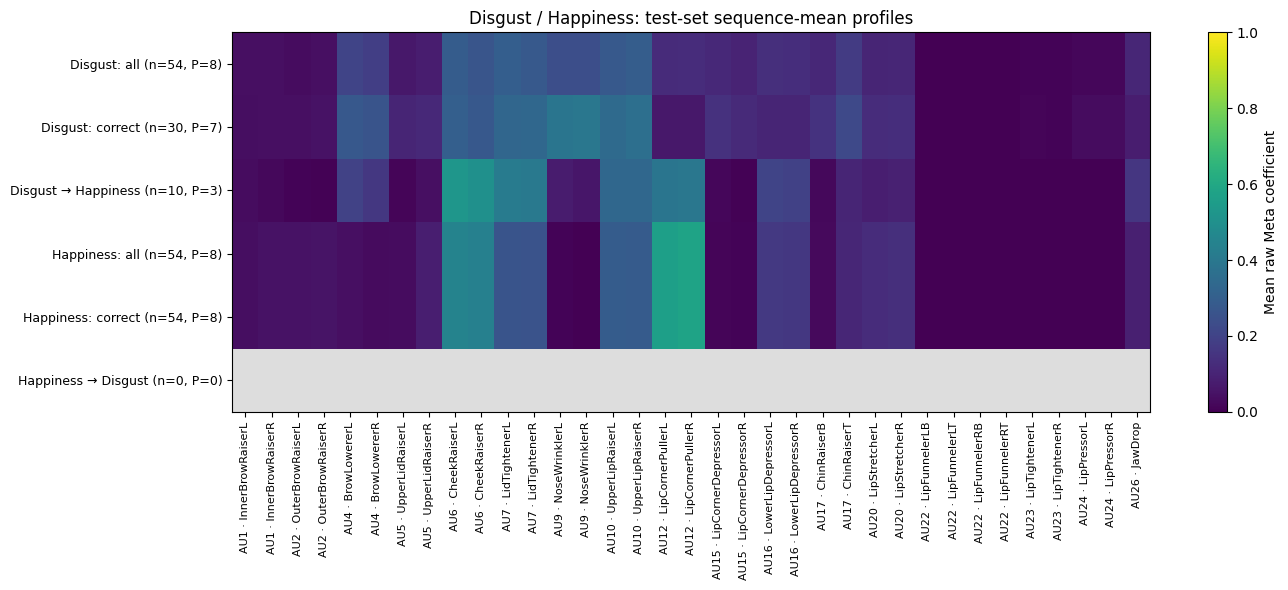

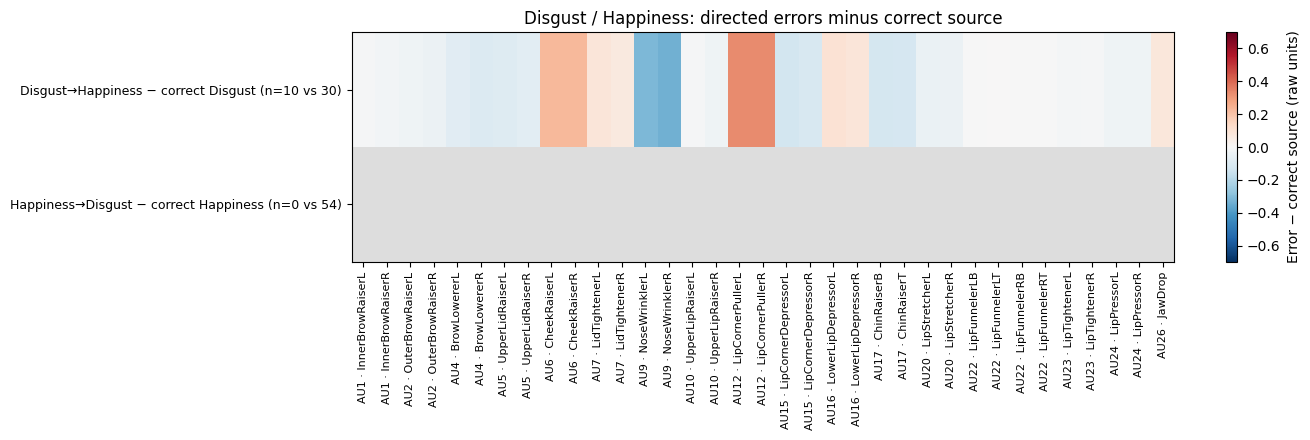

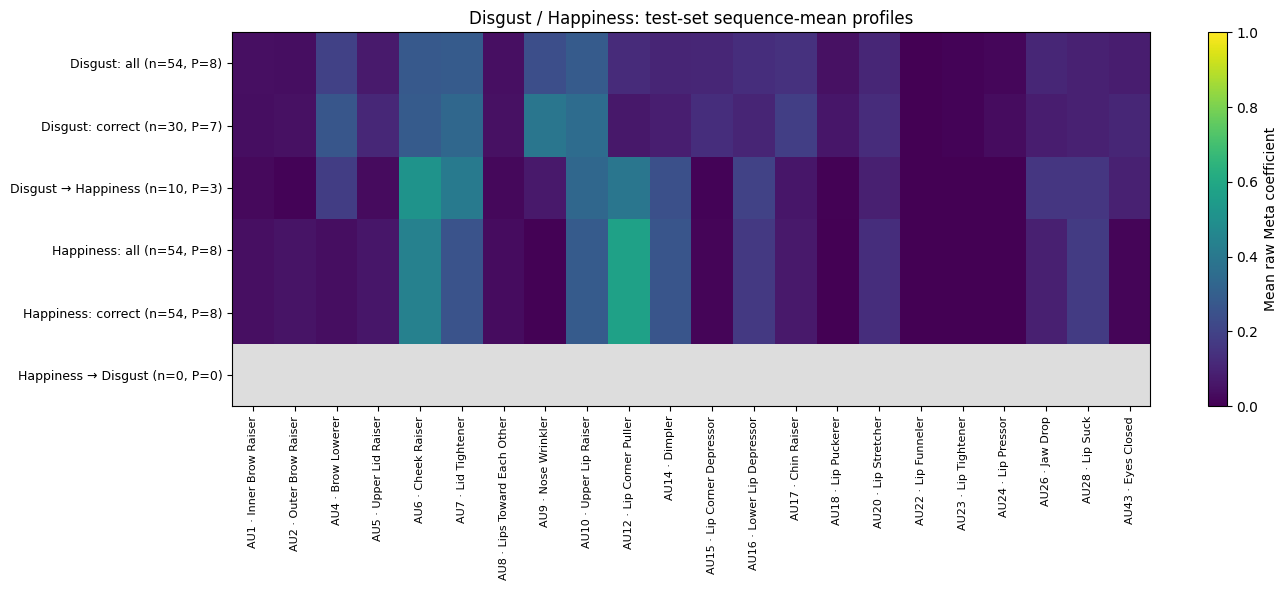

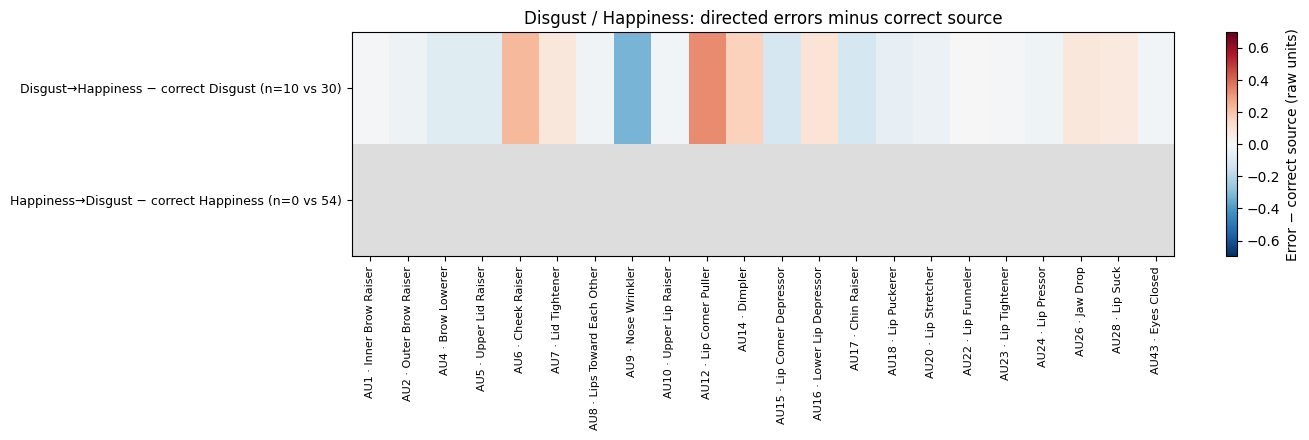

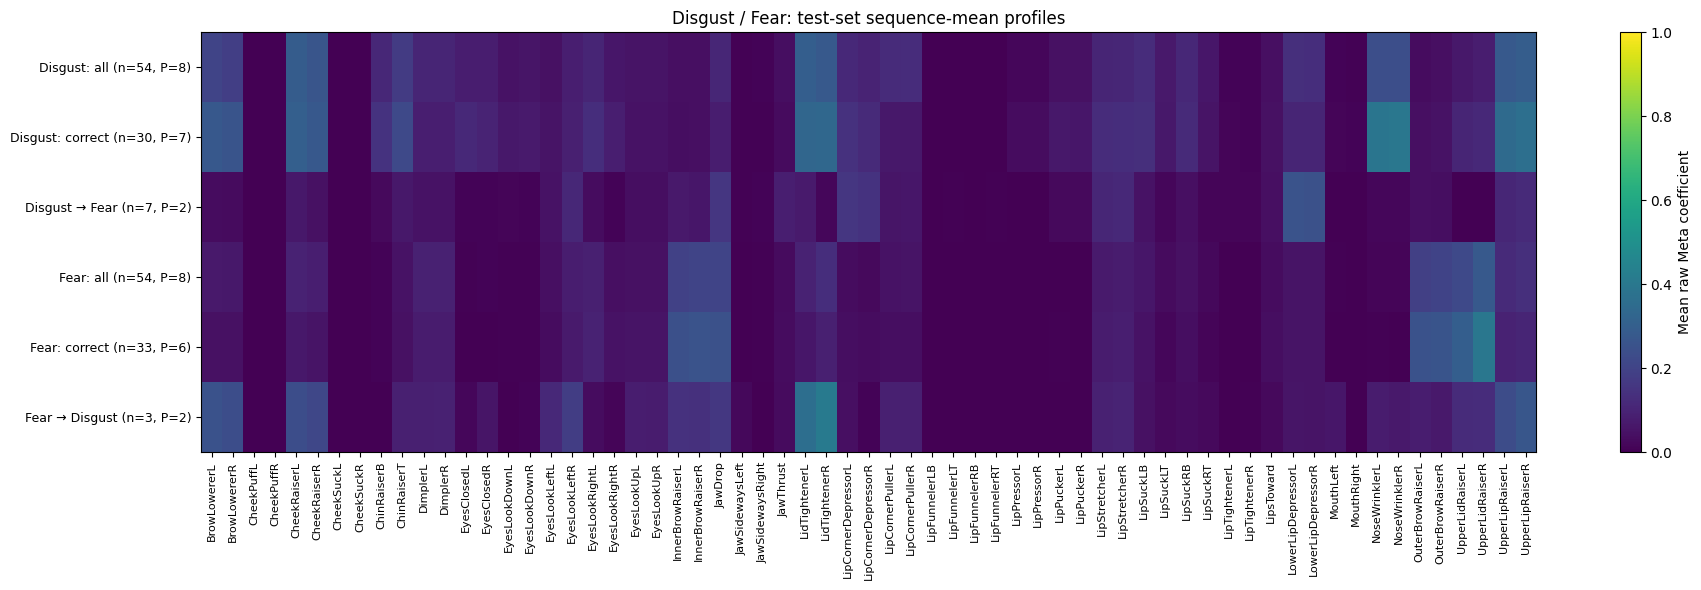

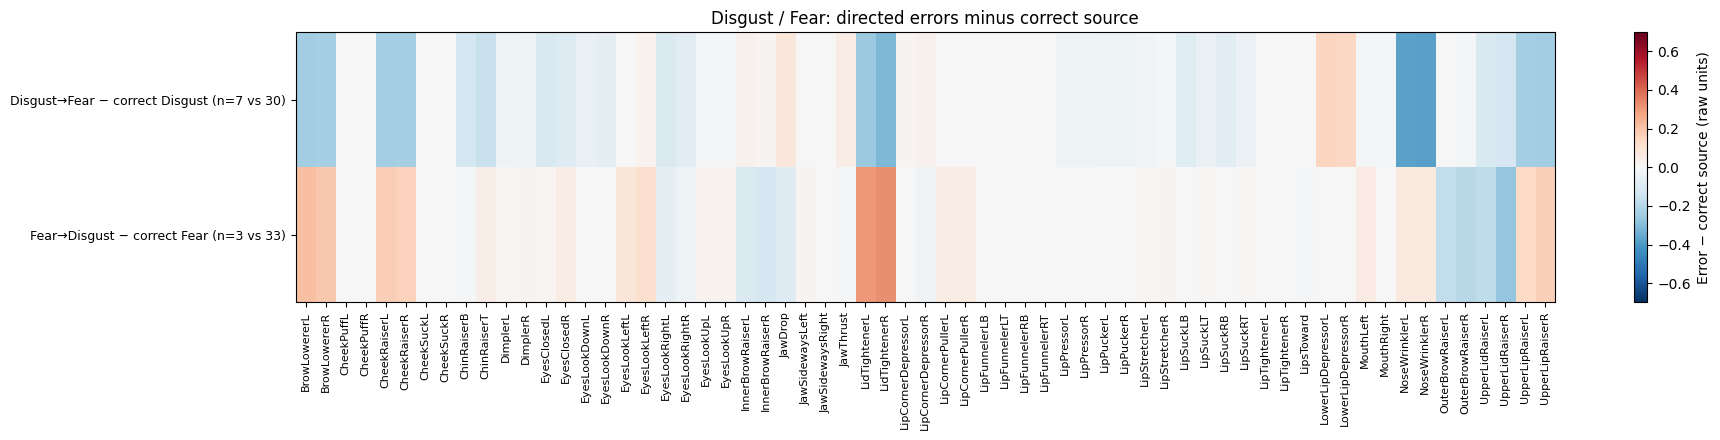

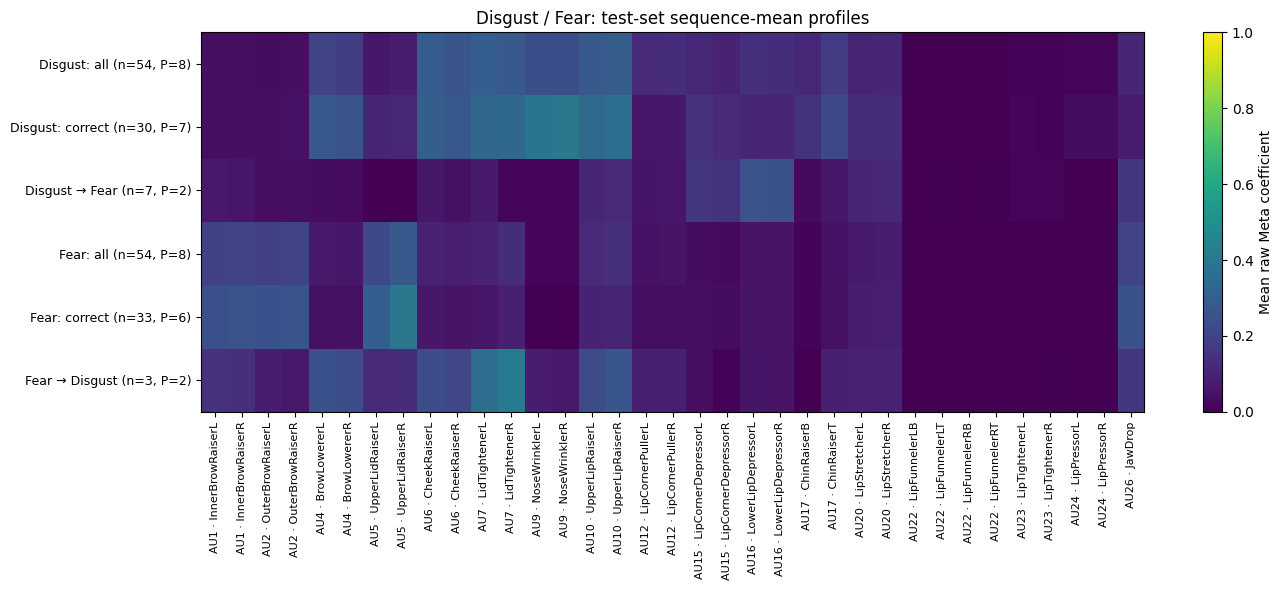

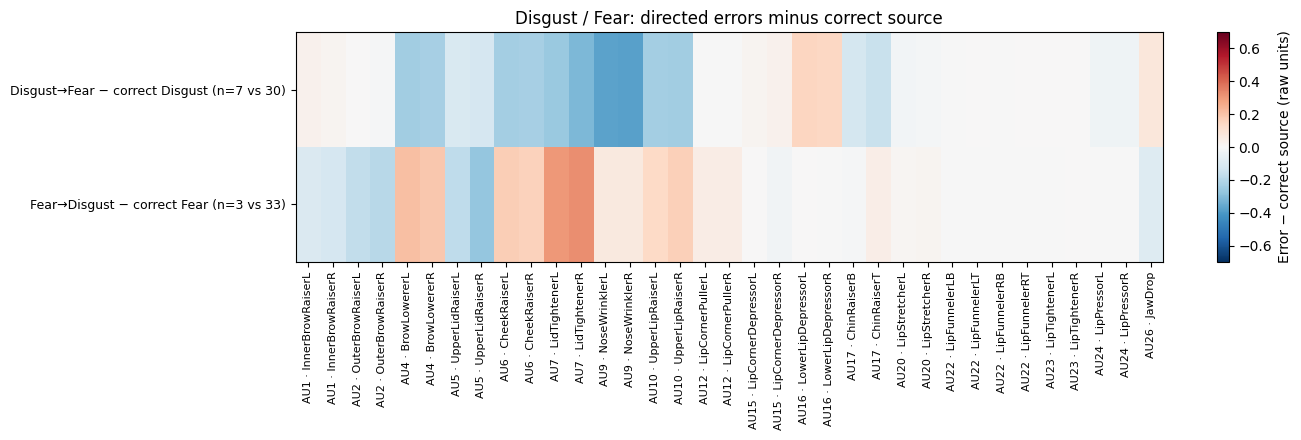

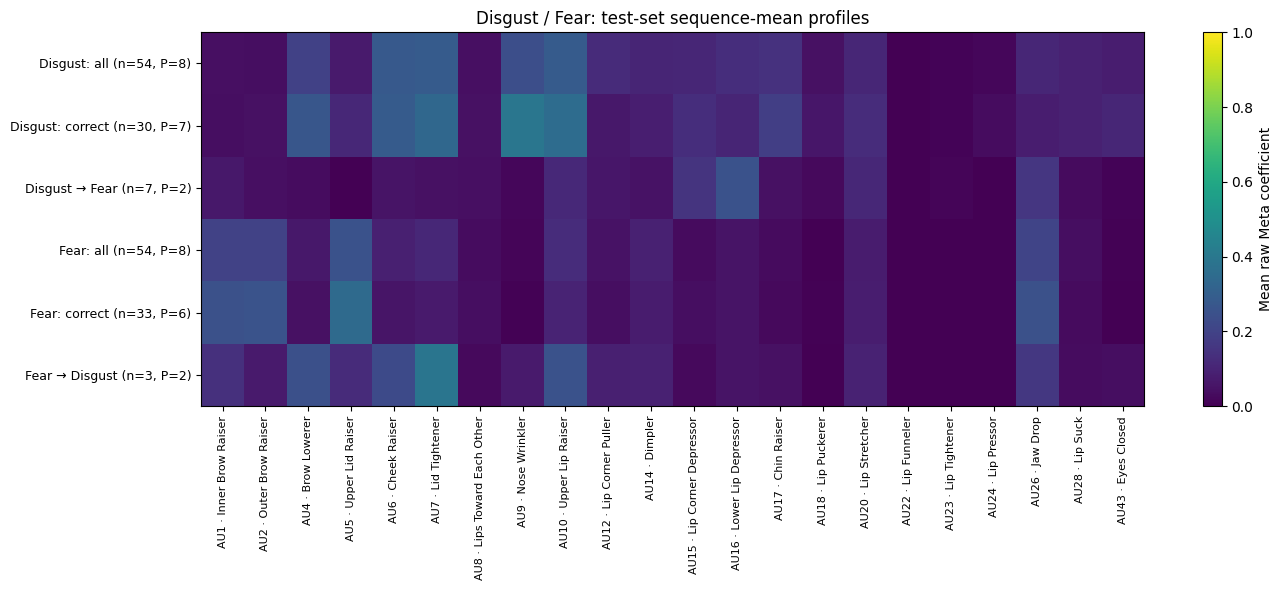

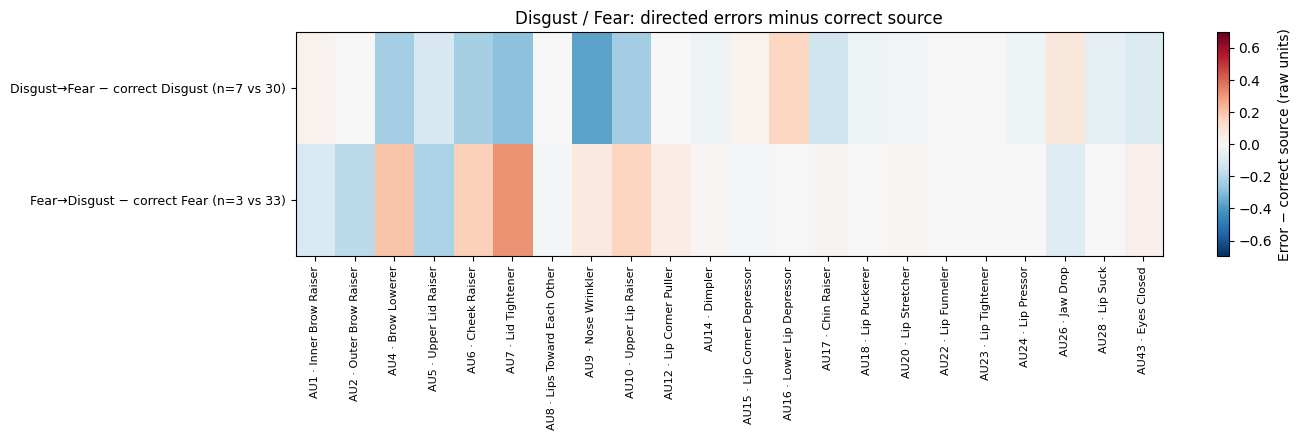

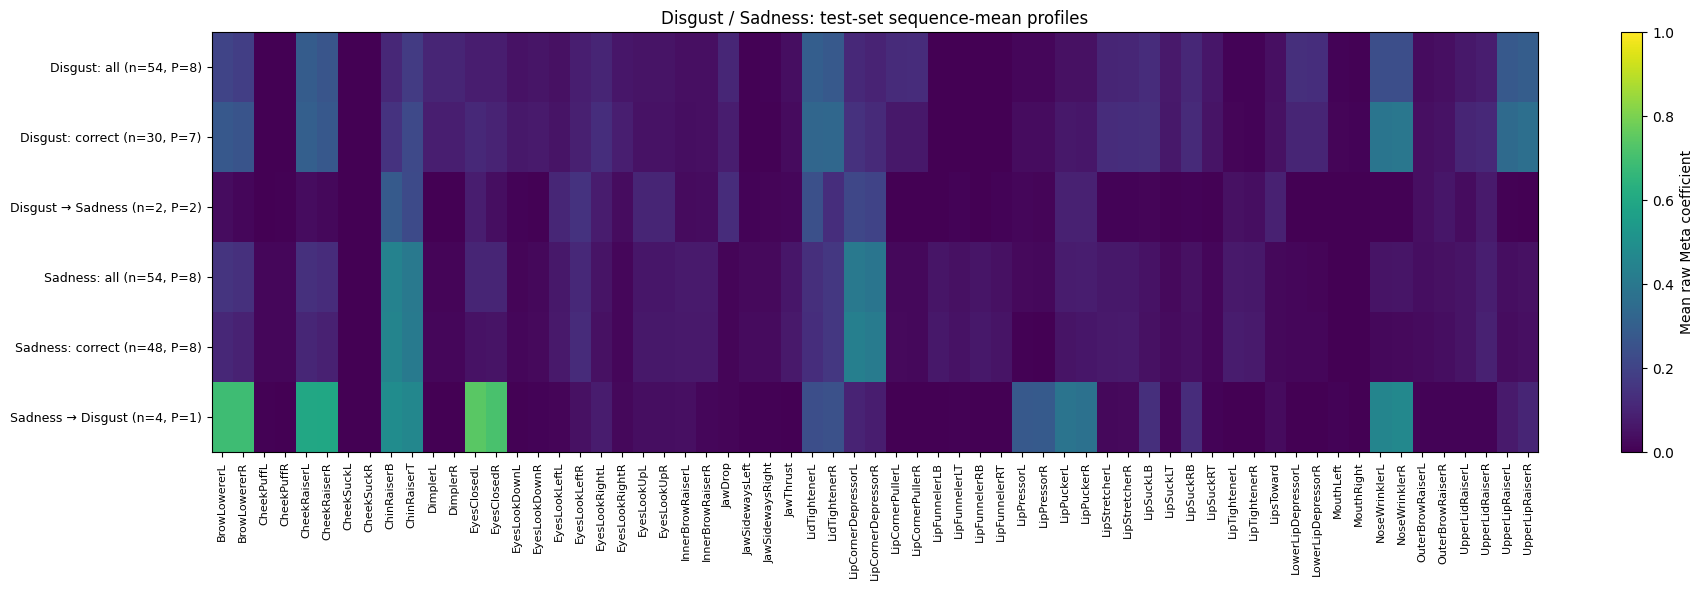

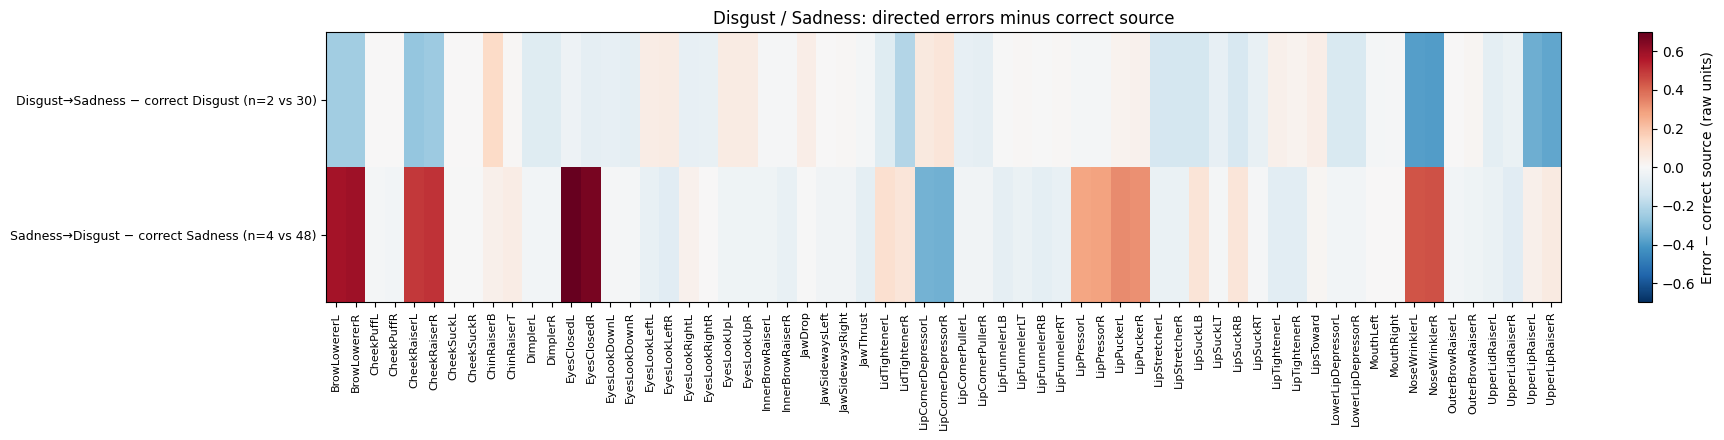

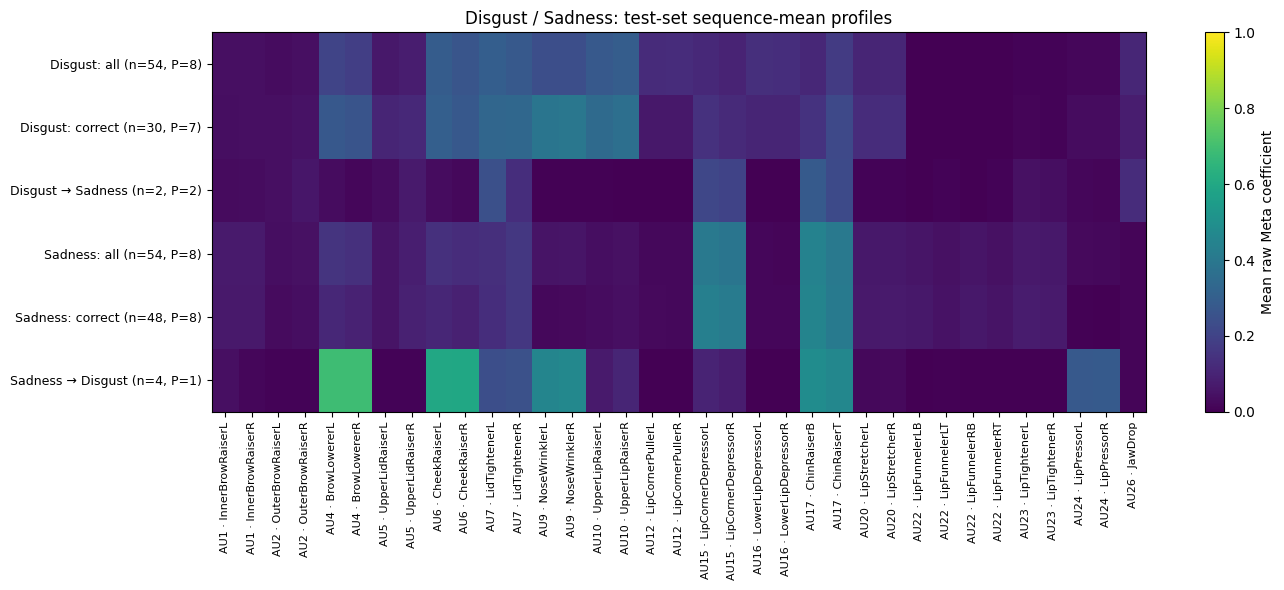

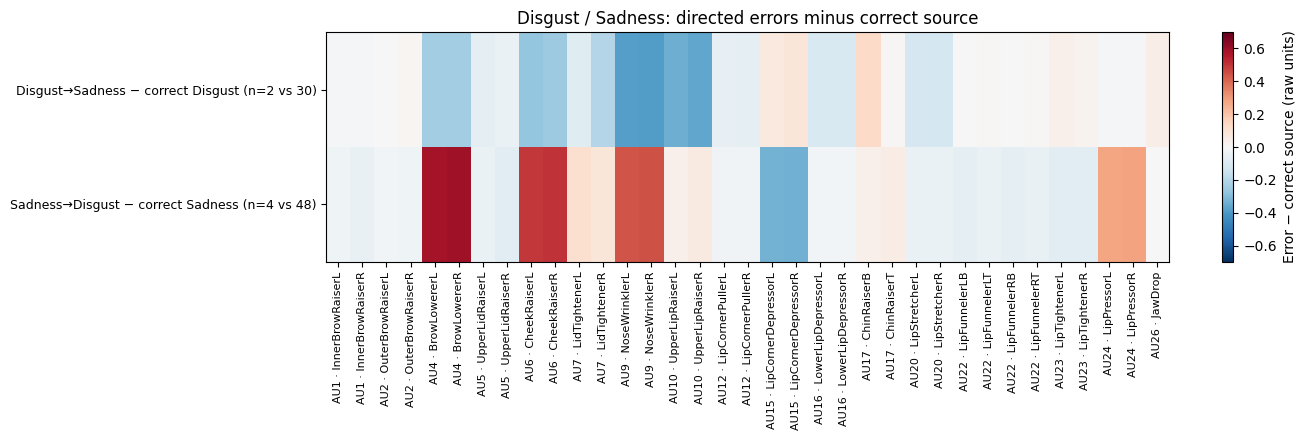

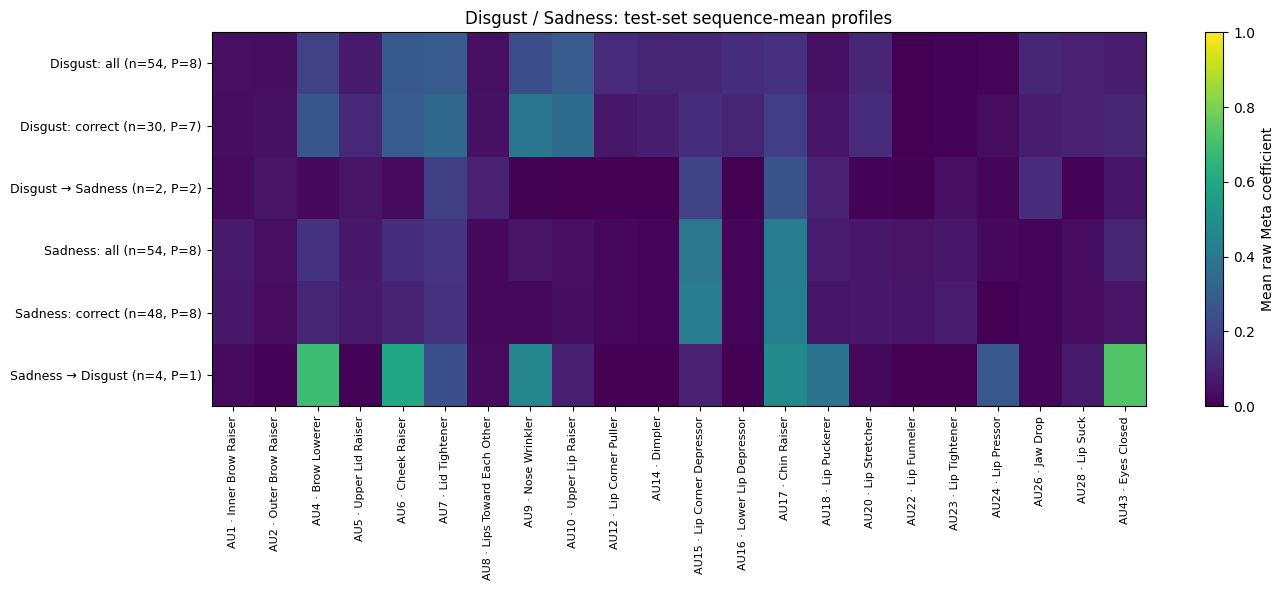

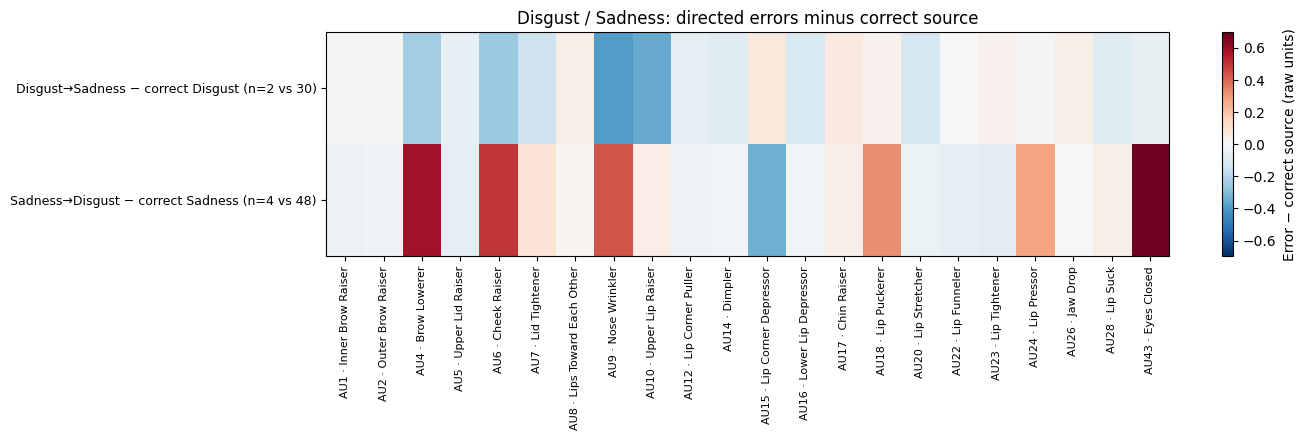

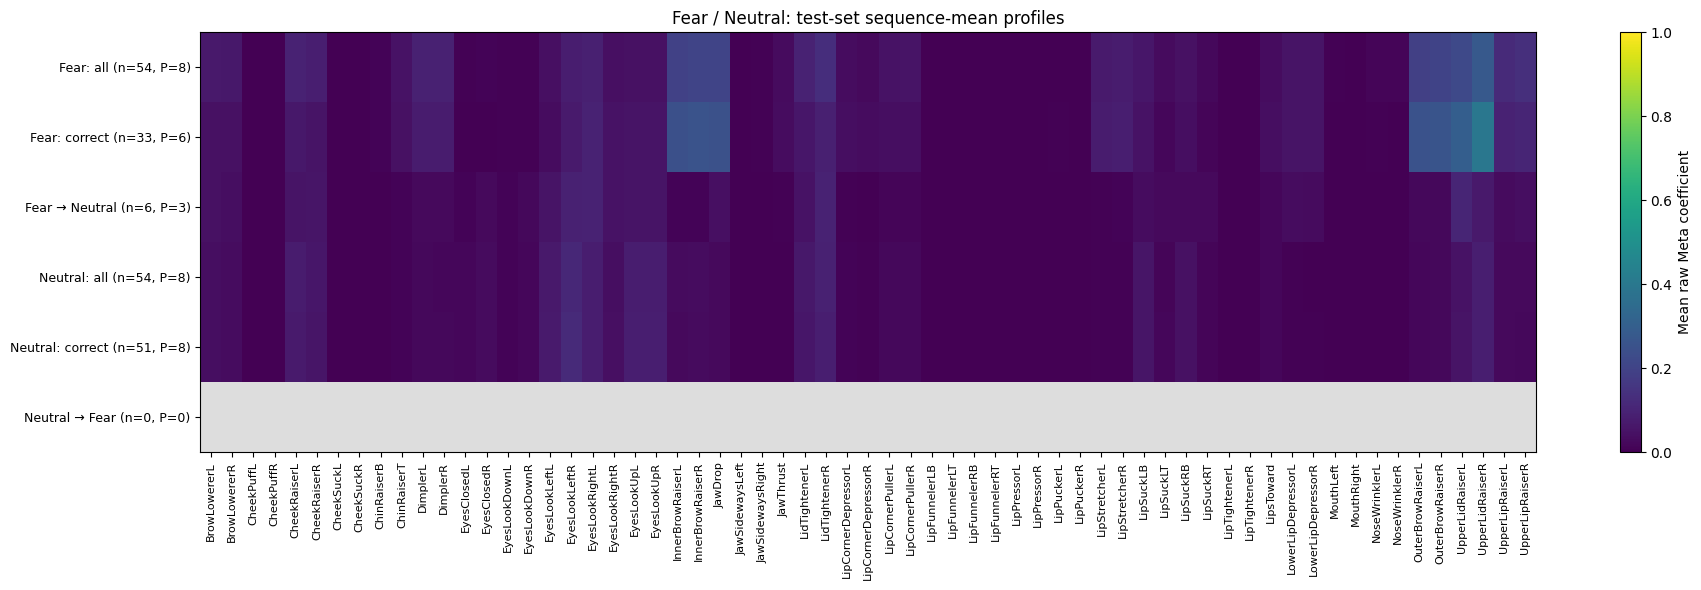

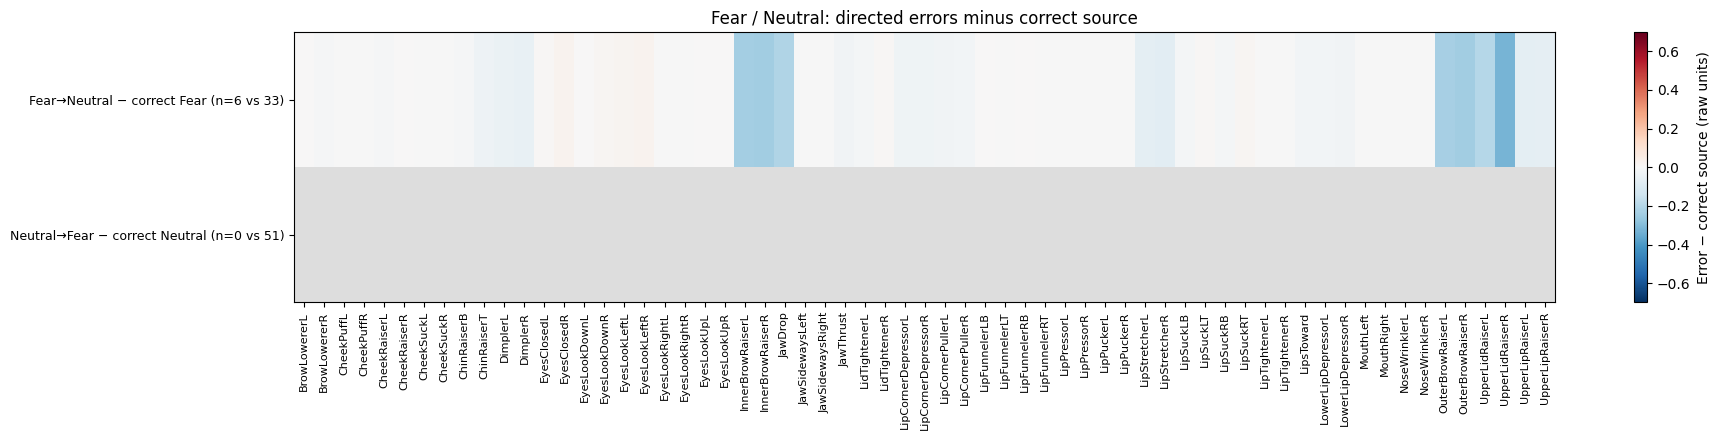

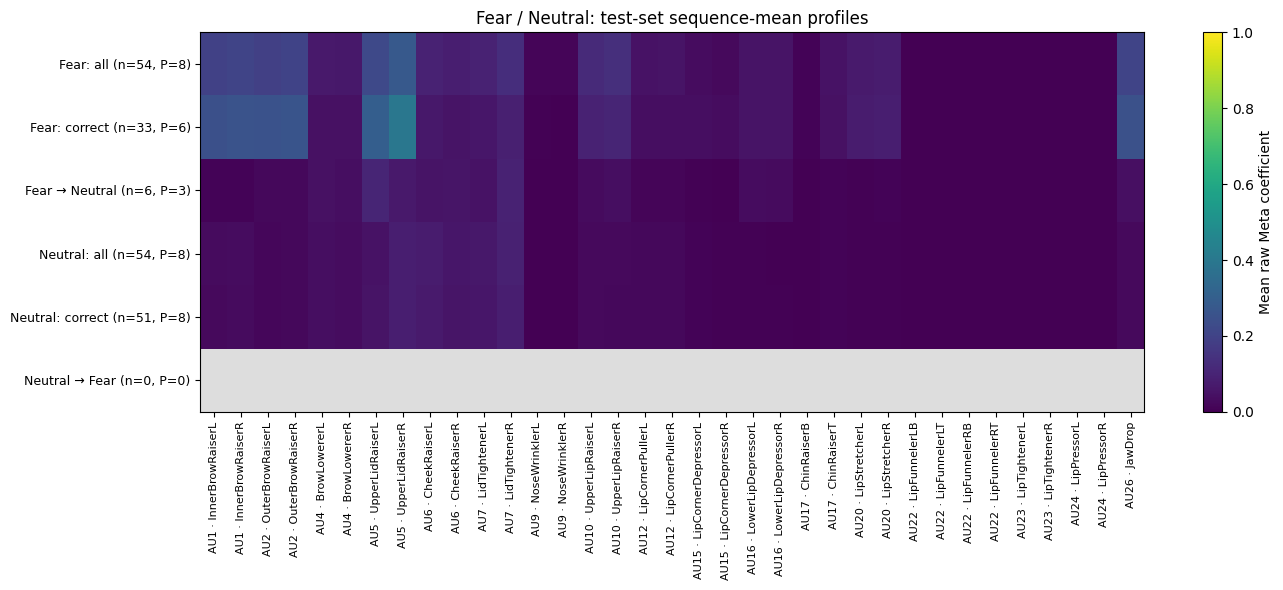

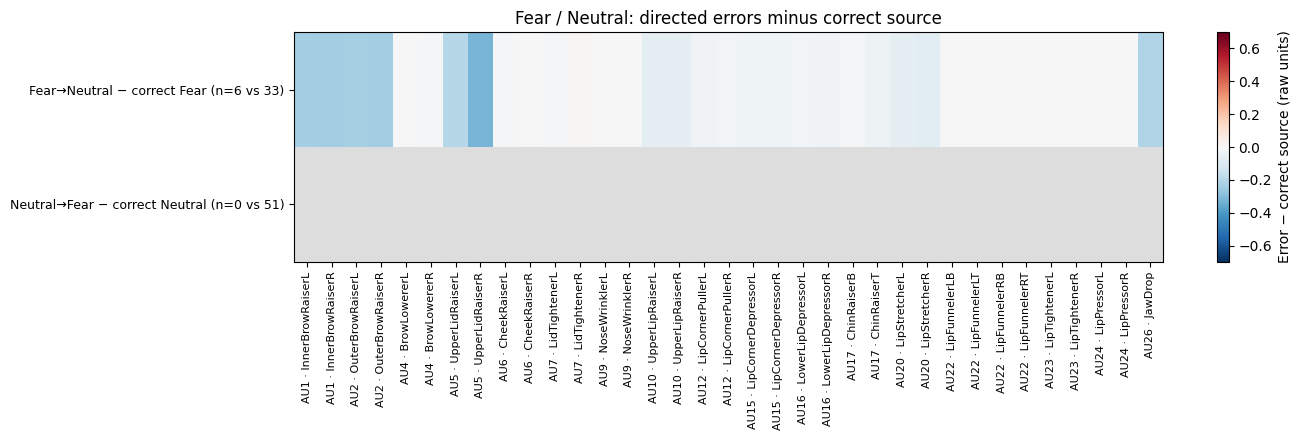

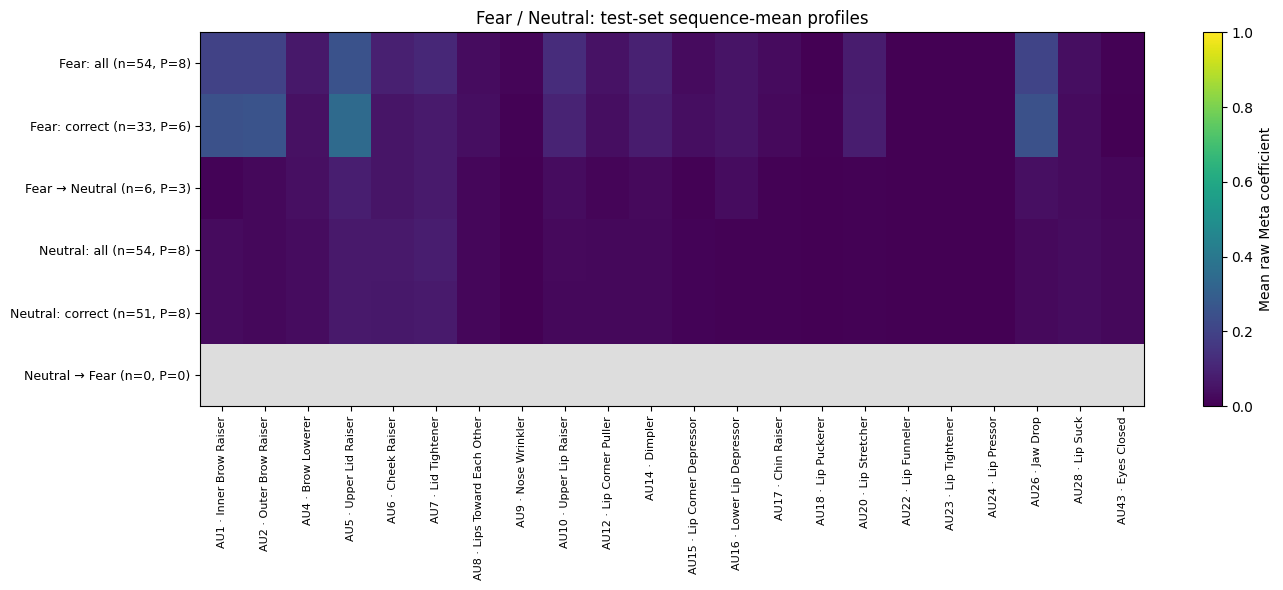

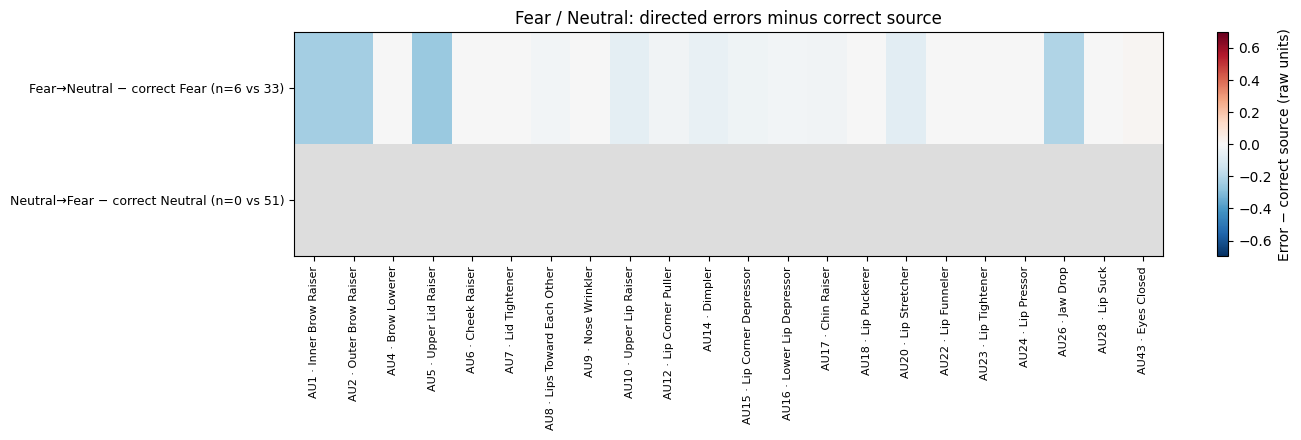

In [17]:
def pair_heatmap(matrix, labels, title, path, difference=False):
    cmap = plt.get_cmap('RdBu_r' if difference else 'viridis').copy()
    cmap.set_bad('#dddddd')
    fig, ax = plt.subplots(figsize=(max(14, .30*len(matrix.columns)), 6 if len(matrix) > 2 else 4.5))
    limit = max(float(primary_contrasts.raw_delta.abs().max()), 1e-9)
    im = ax.imshow(np.ma.masked_invalid(matrix.to_numpy(dtype=float)), aspect='auto', cmap=cmap,
                   vmin=-limit if difference else 0, vmax=limit if difference else 1)
    ax.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=90, fontsize=8)
    ax.set_yticks(range(len(matrix)), labels, fontsize=9)
    ax.set_title(title, fontsize=12)
    fig.colorbar(im, ax=ax, label='Error − correct source (raw units)' if difference else 'Mean raw Meta coefficient')
    fig.tight_layout()
    fig.savefig(path.with_suffix('.png'), dpi=150, bbox_inches='tight')
    fig.savefig(path.with_suffix('.pdf'), bbox_inches='tight')
    plt.show()
    plt.close(fig)

paper_labels = dict(zip(paper_au_fea_pairs.fea_name, paper_au_fea_pairs.heatmap_label))
for a,b in selected_pairs:
    pair = f'{a}__{b}'
    subsets = pair_subsets[pair]
    for name, features, labels in [
        ('all_63', FEA_COLUMNS, {}),
        ('paper_35', PAPER_AU_FEA_COLUMNS, paper_labels),
        ('au_groups', AU_COLUMNS, AU_LABELS),
    ]:
        matrix = pd.DataFrame({k:v[features].mean() for k,v in subsets.items()}).T
        row_labels = [f'{k} (n={len(v)}, P={v.participant_id.nunique()})' for k,v in subsets.items()]
        pair_heatmap(matrix.rename(columns=labels), row_labels,
                     f'{a} / {b}: test-set sequence-mean profiles', PAIR_DIR / f'{pair}_{name}_raw')
        delta = pd.DataFrame([
            subsets[f'{a} → {b}'][features].mean() - subsets[f'{a}: correct'][features].mean(),
            subsets[f'{b} → {a}'][features].mean() - subsets[f'{b}: correct'][features].mean(),
        ])
        delta_labels = []
        for source,target in [(a,b),(b,a)]:
            err=subsets[f'{source} → {target}']; ref=subsets[f'{source}: correct']
            delta_labels.append(f'{source}→{target} − correct {source} (n={len(err)} vs {len(ref)})')
        pair_heatmap(delta.rename(columns=labels), delta_labels,
                     f'{a} / {b}: directed errors minus correct source', PAIR_DIR / f'{pair}_{name}_delta', True)

## 18. Individual-sample distributions for AU-related groups

For each pair, show the three AU-related groups with the largest and the three with the smallest absolute SD-scaled **correct-class mean difference**, without duplicates. This exposes contrasts and similar means without declaring a binary boundary. Selection is exploratory and depends on the correct-only reference; full results remain in CSV.

Dots are reenactment sequence means, colored by participant; black horizontal lines show sample means. Within each panel, the four disjoint subsets are correct A, A→B, correct B, B→A. Unlike all-class references, they do not include the same sample twice. Empty subsets are explicitly labeled. Similar means with wide scatter must not be read as interchangeable signals.

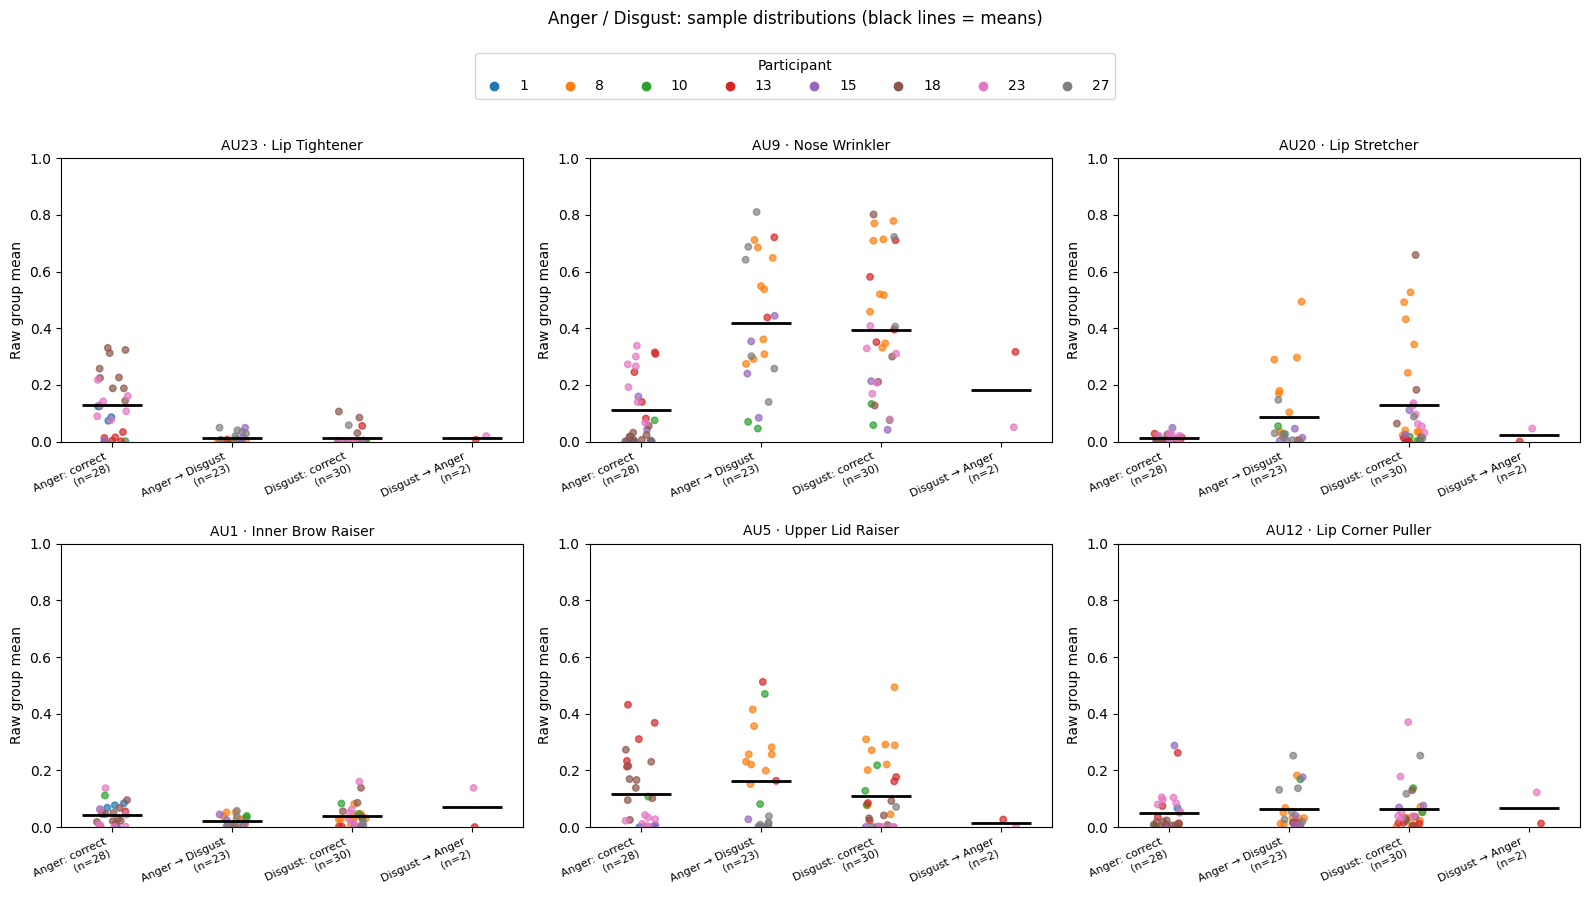

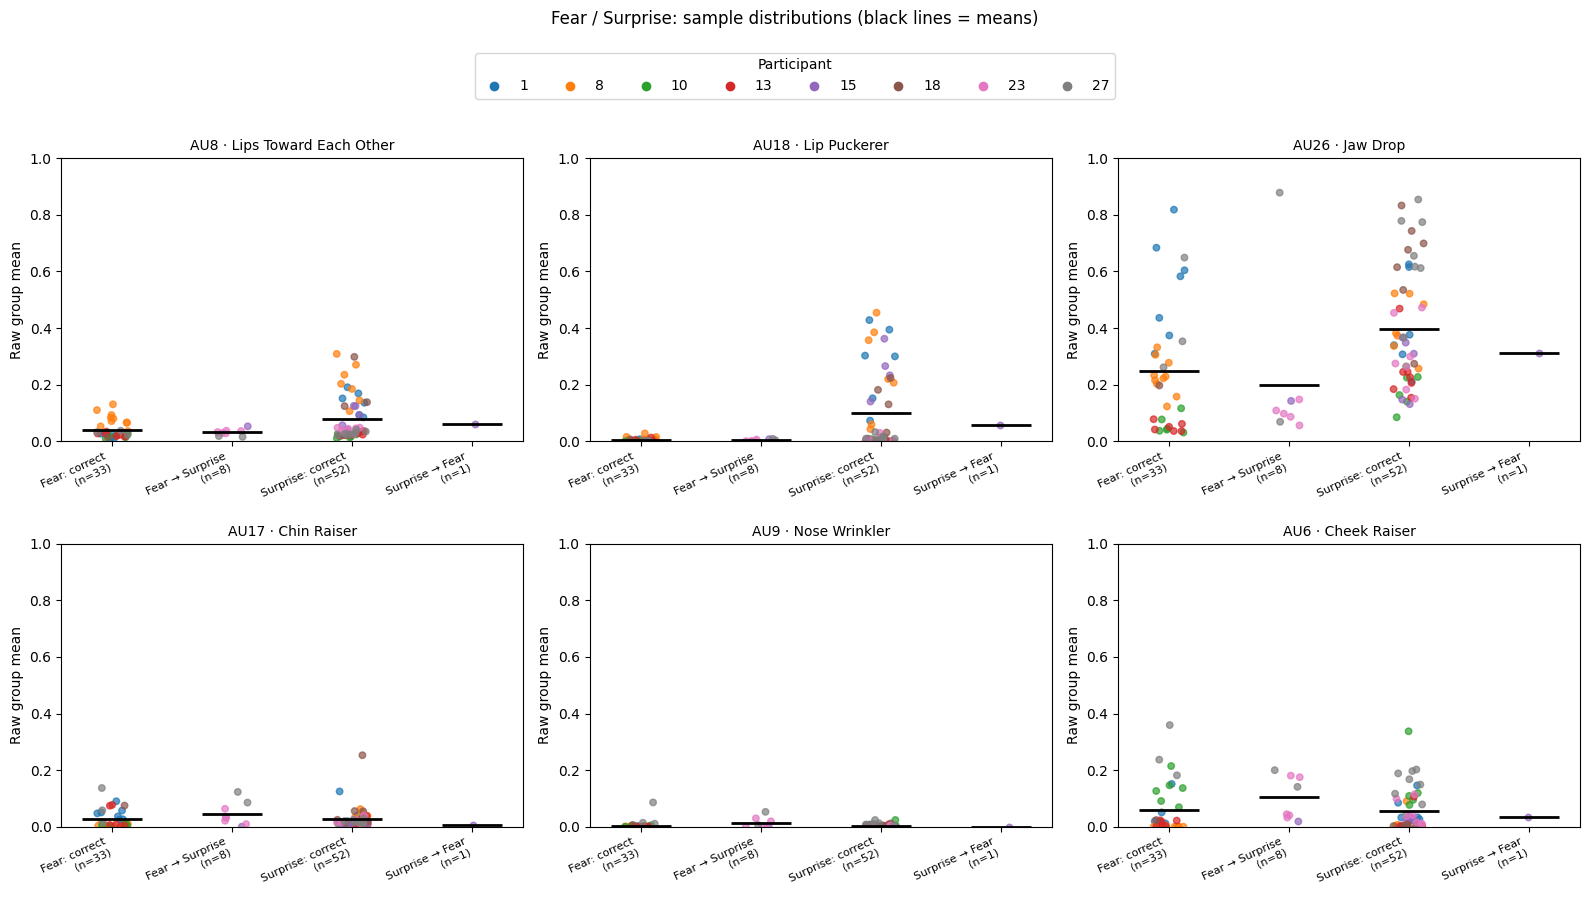

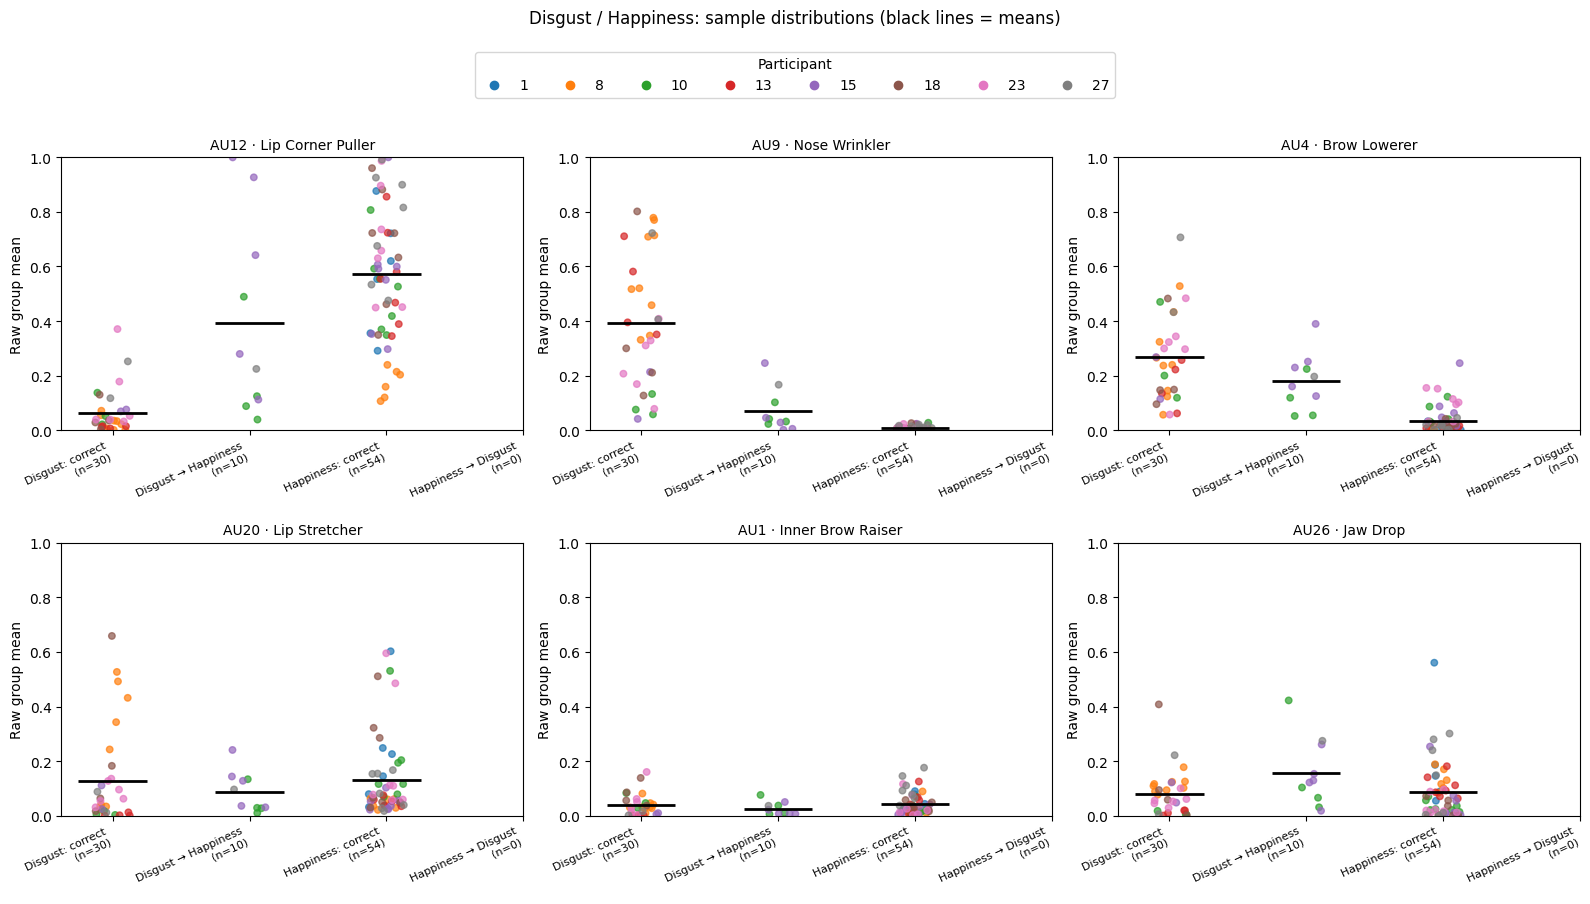

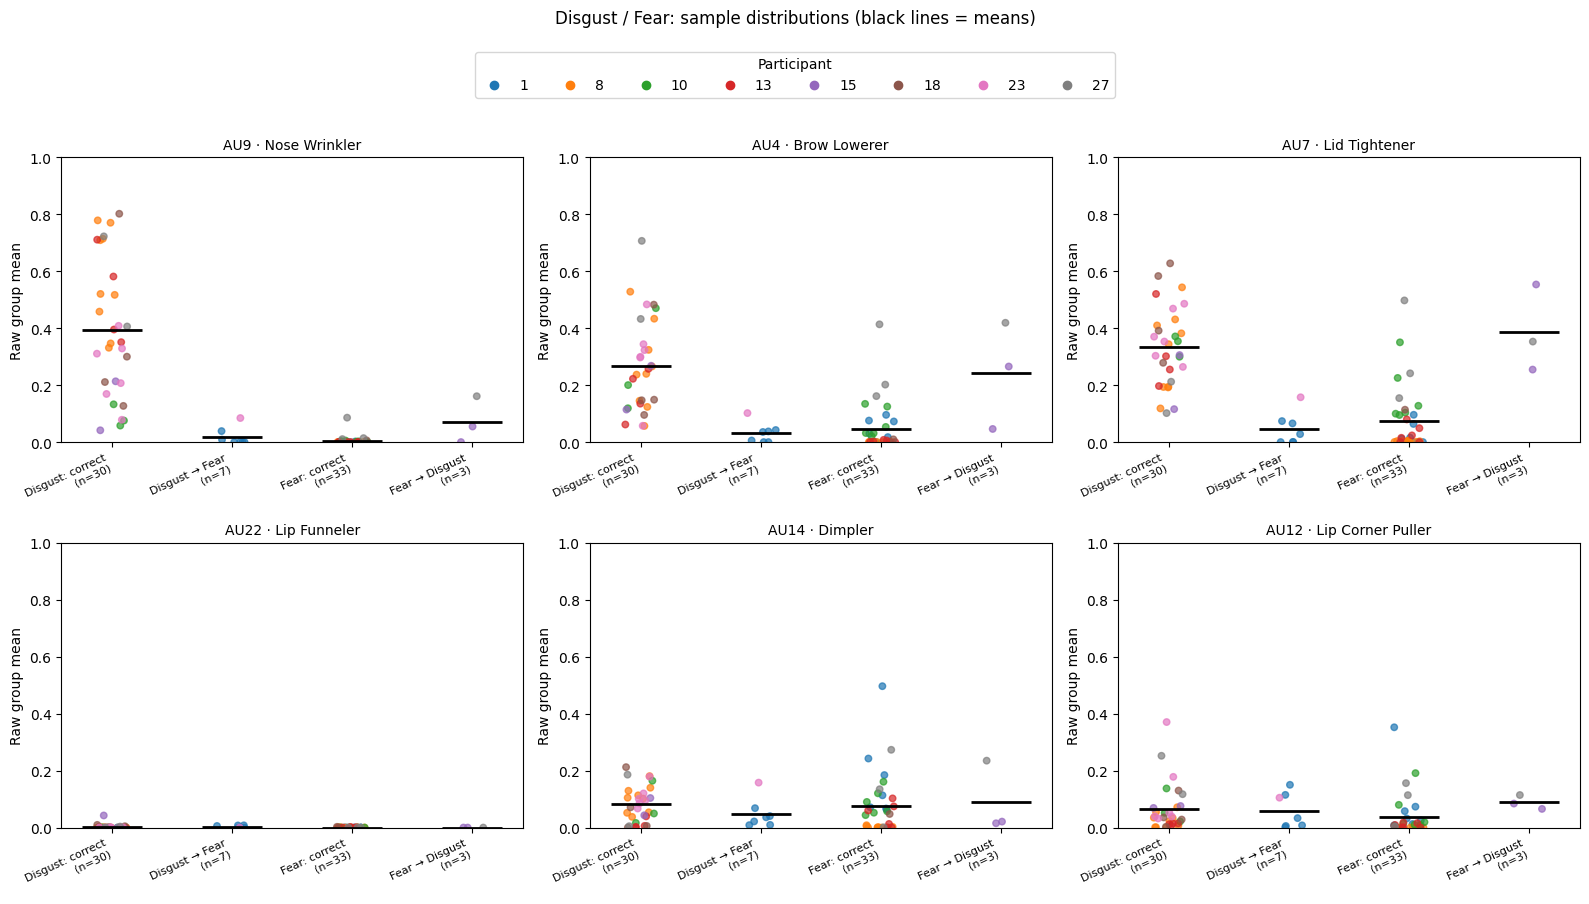

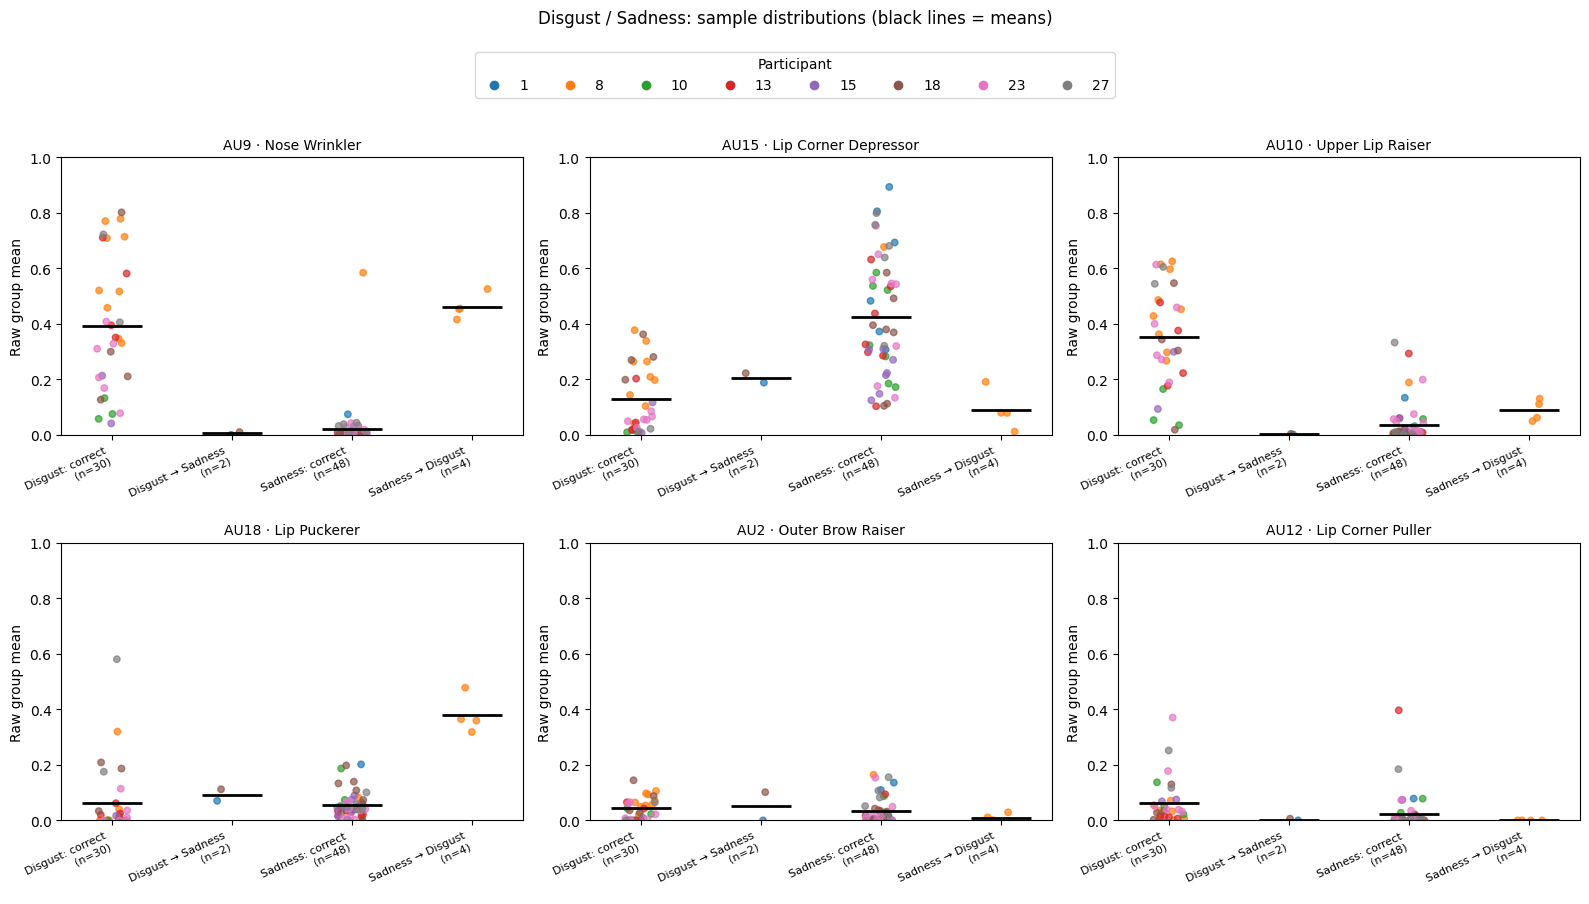

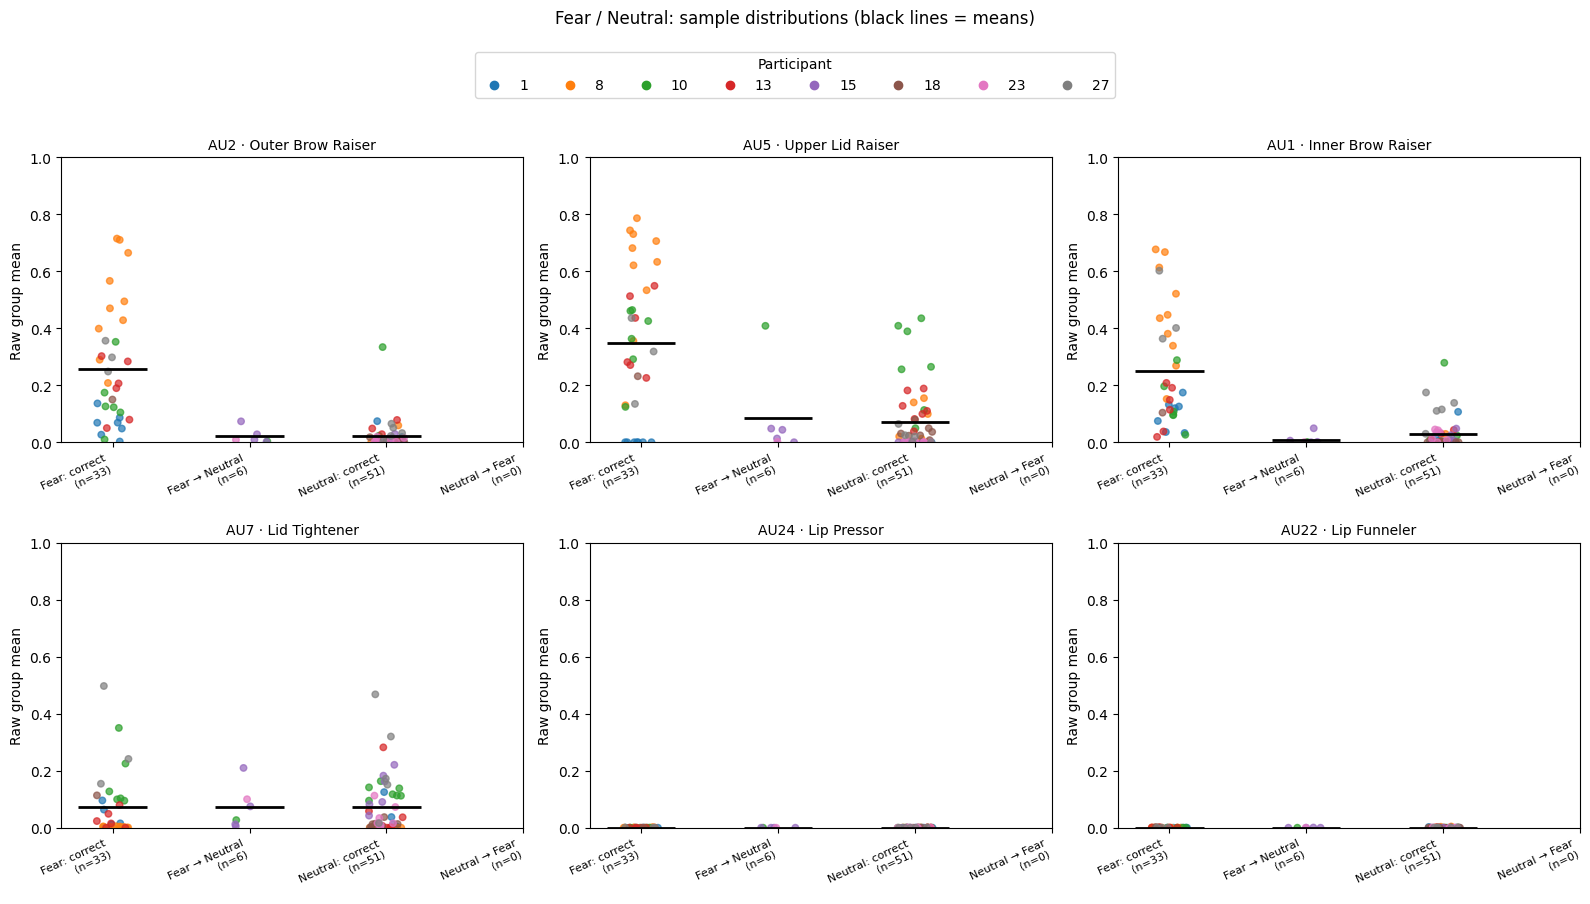

In [18]:
participant_ids = sorted(analysis_df.participant_id.unique())
participant_colors = dict(zip(participant_ids, plt.get_cmap('tab10').colors))
rng = np.random.default_rng(20260920)
for a,b in selected_pairs:
    pair = f'{a}__{b}'
    ranked = class_differences.loc[(class_differences.pair == pair) &
        (class_differences.basis == 'correct') & (class_differences.kind == 'AU-related group')].dropna(subset=['abs_sd_delta']).sort_values('abs_sd_delta')
    chosen = list(dict.fromkeys(ranked.tail(3).iloc[::-1].feature.tolist() + ranked.head(3).feature.tolist()))
    subsets = pair_subsets[pair]
    names = [f'{a}: correct',f'{a} → {b}',f'{b}: correct',f'{b} → {a}']
    fig, axes = plt.subplots(2,3,figsize=(16,9),squeeze=False)
    for ax, feature in zip(axes.flat, chosen):
        for x,label in enumerate(names):
            group = subsets[label]
            ax.scatter(x+rng.uniform(-.13,.13,len(group)), group[feature],
                       c=[participant_colors[p] for p in group.participant_id], alpha=.7, s=22)
            if len(group): ax.hlines(group[feature].mean(), x-.25,x+.25,color='black',lw=2)
        ax.set_xticks(range(4), [f'{k}\n(n={len(subsets[k])})' for k in names], rotation=25,ha='right',fontsize=8)
        ax.set_ylim(0,1); ax.set_ylabel('Raw group mean'); ax.set_title(AU_LABELS[feature],fontsize=10)
    for ax in list(axes.flat)[len(chosen):]:ax.axis('off')
    from matplotlib.lines import Line2D
    fig.legend(handles=[Line2D([0],[0],marker='o',linestyle='',color=participant_colors[p],label=str(p)) for p in participant_ids],
               title='Participant',loc='upper center',ncol=len(participant_ids),bbox_to_anchor=(.5,.96))
    fig.suptitle(f'{a} / {b}: sample distributions (black lines = means)',y=1)
    fig.tight_layout(rect=(0,0,1,.91))
    fig.savefig(PAIR_DIR / f'{pair}_sample_distributions.png',dpi=150,bbox_inches='tight')
    fig.savefig(PAIR_DIR / f'{pair}_sample_distributions.pdf',bbox_inches='tight')
    plt.show(); plt.close(fig)

## 19. Append results and interpretation to the Markdown report

All numerical statements below are generated from the current inputs. Feature-specific movement toward the correct target mean is assessed by comparing the error-to-target absolute gap with the correct-source-to-target gap; a reduced gap is descriptive proximity for that channel, not evidence about the classifier's decision rule. No global claim about class resemblance is inferred from a few ranked channels.

In [19]:
sections = ["## Directed confusion analysis", "Only test reenactments are used; sequence means, raw coefficients, and sample weighting are retained. Trajectories are deferred.",
    markdown_table(pair_selection, pair_selection.columns.tolist()),
    "The pair list includes the requested pairs and the five most frequent unordered error pairs, with ties. Results are exploratory; selection and rankings do not constitute statistical tests.",
    "### Reference definitions", "Primary: A→B versus correctly classified A. All-A and all-B references and correctly classified B are also exported. All-A contains A→B, so these are overlapping descriptive references, not independent groups.",
    "Raw plots use [0,1]; signed plots share one symmetric scale. Gray rows are unavailable. SD-scaled differences use the full-test sequence-summary SD, not a within-pair pooled SD. Semantic group means are not validated AU measurements."]
for a,b in selected_pairs:
    pair = f'{a}__{b}'
    sections += [f'### {a} versus {b}', markdown_table(coverage.loc[coverage.pair.eq(pair)], ['subset','n','participants']),
        f'Figures: `confusion_pairs/{pair}_paper_35_raw.png`, `{pair}_all_63_raw.png`, `{pair}_au_groups_raw.png`; corresponding `_delta.png` files show directed contrasts. `confusion_pairs/{pair}_sample_distributions.png` shows individual samples colored by participant. PDF versions are also saved.']
    cd = class_differences.loc[class_differences.pair.eq(pair) & class_differences.basis.eq('correct') & class_differences.kind.eq('AU-related group')].dropna(subset=['abs_sd_delta']).sort_values('abs_sd_delta',ascending=False)
    sections += ['Largest correct-class mean contrasts (B minus A):',markdown_table(cd.head(5), ['feature','a_mean','b_mean','raw_delta_b_minus_a','sd_scaled_delta']),
        'Most similar correct-class group means:', markdown_table(cd.tail(5).sort_values('abs_sd_delta'), ['feature','a_mean','b_mean','a_sd','b_sd','raw_delta_b_minus_a']),
        'Similar means do not establish distributional equivalence; consult sample distributions and the exported SDs and quartiles.']
    for source,target in [(a,b),(b,a)]:
        subset = pair_subsets[pair][f'{source} → {target}']
        own = primary_contrasts.loc[primary_contrasts.pair.eq(pair) & primary_contrasts.source.eq(source)]
        n_source = len(pair_subsets[pair][f'{source}: all'])
        sections.append(f'#### {source} → {target}: {len(subset)}/{n_source} source-class samples ({len(subset)/n_source:.1%}), {subset.participant_id.nunique()} participants')
        if subset.empty:
            sections.append('No observed errors in this direction; no error profile or contrast is estimated.')
            continue
        pcounts = subset.groupby('participant_id').size()
        sections.append(f'The largest participant contribution is {pcounts.max()}/{len(subset)} error samples. Small or concentrated groups should be interpreted as case descriptions, not stable class effects.')
        top = own.loc[own.kind.eq('FEA')].dropna(subset=['sd_scaled_delta']).head(5)
        sections += ['Largest individual-channel changes, ranked by absolute SD-scaled difference:',markdown_table(top,
            ['feature','error_mean','reference_mean','raw_delta','sd_scaled_delta','shared_participants','within_participant_delta'])]
        groups = own.loc[own.kind.eq('AU-related group')].dropna(subset=['sd_scaled_delta']).head(5)
        sections += ['Largest semantic AU-related group changes:',markdown_table(groups,['feature','error_mean','reference_mean','raw_delta','sd_scaled_delta'])]
        for row in groups.head(3).itertuples():
            target_mean = pair_subsets[pair][f'{target}: correct'][row.feature].mean()
            before = abs(row.reference_mean - target_mean); after = abs(row.error_mean - target_mean)
            relation = 'smaller' if after < before else ('larger' if after > before else 'unchanged')
            sections.append(f'- {AU_LABELS[row.feature]}: errors average {row.error_mean:.3f}, versus {row.reference_mean:.3f} for correct {source} and {target_mean:.3f} for correct {target}. The absolute gap to the target reference is {relation} ({before:.3f} → {after:.3f}). This is a channel-specific descriptive comparison.')
        shared = int(own.shared_participants.iloc[0])
        sections.append(f'Same-participant sensitivity: {shared} participants supply both error and correct-source samples. The CSV includes their individual differences and positive/negative direction counts. A missing estimate means no shared participant; differing signs can reflect composition and weighting and must not be ignored.')
sections += ['### Interpretation boundaries and complete outputs',
    'Correct-only and all-class references, all individual-channel and AU-related group contrasts, SDs/quartiles, participant counts, and identifiers of the confused reenactments are exported under `confusion_pairs/`. Files: `raw_profiles_and_distributions.csv`, `all_directed_contrasts.csv`, `class_reference_differences.csv`, `participant_counts.csv`, `confused_sample_sequence_means.csv`.',
    'These comparisons describe signals associated with observed errors. They do not demonstrate causation, model reliance, statistical significance, binary AU presence, or internal emotional states. Sample means can conceal multimodality and participant-specific patterns. Temporal information is deliberately omitted; no claims about temporal phases or trajectories are made.']
confusion_report_text = '\n\n'.join(sections)
report = report + '\n\n' + confusion_report_text
report_path.write_text(report, encoding='utf-8')
print(confusion_report_text)
print('Saved:', report_path)

## Directed confusion analysis

Only test reenactments are used; sequence means, raw coefficients, and sample weighting are retained. Trajectories are deferred.

| class_a | class_b | errors_both_directions |
| --- | --- | --- |
| Anger | Disgust | 25 |
| Fear | Surprise | 9 |
| Disgust | Happiness | 10 |
| Disgust | Fear | 10 |
| Disgust | Sadness | 6 |
| Fear | Neutral | 6 |

The pair list includes the requested pairs and the five most frequent unordered error pairs, with ties. Results are exploratory; selection and rankings do not constitute statistical tests.

### Reference definitions

Primary: A→B versus correctly classified A. All-A and all-B references and correctly classified B are also exported. All-A contains A→B, so these are overlapping descriptive references, not independent groups.

Raw plots use [0,1]; signed plots share one symmetric scale. Gray rows are unavailable. SD-scaled differences use the full-test sequence-summary SD, not a within-pair pooled SD. Semantic grou

## 20. Output inventory

In [20]:
for path in sorted(OUTPUT_DIR.rglob('*')):
    if path.is_file():
        print(f'{str(path.relative_to(OUTPUT_DIR)):85s} {path.stat().st_size/1024:9.1f} KiB')

all_63_feas_correct_raw.pdf                                                                28.2 KiB
all_63_feas_correct_raw.png                                                               326.0 KiB
all_63_feas_incorrect_minus_correct_raw.pdf                                                29.8 KiB
all_63_feas_incorrect_minus_correct_raw.png                                               359.7 KiB
all_63_feas_incorrect_raw.pdf                                                              29.2 KiB
all_63_feas_incorrect_raw.png                                                             321.4 KiB
confusion_pairs/Anger__Disgust_all_63_delta.pdf                                            24.1 KiB
confusion_pairs/Anger__Disgust_all_63_delta.png                                           140.8 KiB
confusion_pairs/Anger__Disgust_all_63_raw.pdf                                              27.4 KiB
confusion_pairs/Anger__Disgust_all_63_raw.png                                             157.1 KiB
